# 6.3 Mini-project: Applying supervised learning to predict student dropout

**Welcome to your Mini-project: Applying supervised learning to predict student dropout rate**

In this project, we will examine student data and use supervised learning techniques to predict whether a student will drop out. In the education sector, retaining students is vital for the institution's financial stability and for students’ academic success and personal development. A high dropout rate can lead to significant revenue loss, diminished institutional reputation, and lower overall student satisfaction.

You will work with the data in three distinct stages:

1.  Applicant and course information
2.  Student and engagement data
3.  Academic performance data

These stages reflect Study Group’s real-world data journey and how student information has progressed and become available. Additionally, this approach enables you, through data exploration, to support Study Group in better understanding and identifying key metrics to monitor. This approach will also assist you in determining at which stage of the student journey interventions would be most effective.

Please set aside approximately **12 hours** to complete the mini-project.

## Business context
Study Group specialises in providing educational services and resources to students and professionals across various fields. The company's primary focus is on enhancing learning experiences through a range of services, including online courses, tutoring, and educational consulting. By leveraging cutting-edge technology and a team of experienced educators, Study Group aims to bridge the gap between traditional learning methods and the evolving needs of today's learners.

Study Group serves its university partners by establishing strategic partnerships to enhance the universities’ global reach and diversity. It supports the universities in their efforts to attract international students, thereby enriching the cultural and academic landscape of their campuses. It works closely with university faculty and staff to ensure that the universities are prepared and equipped to welcome and support a growing international student body. Its partnership with universities also offers international students a seamless transition into their chosen academic environment.

Study Group runs several International Study Centres across the UK and Dublin in partnership with universities with the aim of preparing a pipeline of talented international students from diverse backgrounds for degree study. These centres help international students adapt to the academic, cultural, and social aspects of studying abroad. This is achieved by improving conversational and subject-specific language skills and academic readiness before students progress to a full degree programme at university.

Through its comprehensive suite of services, it supports learners and universities at every stage of their educational journey, from high school to postgraduate studies. Its approach is tailored to meet the unique needs of each learner, offering personalised learning paths and flexible scheduling options to accommodate various learning styles and commitments.

Study Group's services are designed to be accessible and affordable, making quality education a reality for many individuals. By focusing on the integration of technology and personalised learning, the company aims to empower learners to achieve their full potential and succeed in their academic and professional pursuits. Study Group is at the forefront of transforming how people learn and grow through its dedication to innovation and excellence.

Study Group has provided you with 3 data sets.


## Objective
By the end of this mini-project, you will have developed the skills and knowledge to apply advanced machine learning techniques to create a predictive model for student dropout. This project will involve comprehensive data exploration, preprocessing, and feature engineering to ensure high-quality input for the models. You will employ and compare multiple predictive algorithms, such as XGBoost, and a neural network-based model, to determine the most effective model for predicting student dropout.

In the Notebook, you will:
- explore the data sets, taking a phased approach
- preprocess the data and conduct feature engineering
- predict the dropout rate using XGBoost, and a neural network-based model.

You will also write a report summarising the results of your findings and recommendations.

## Assessment criteria
By completing this project, you’ll be able to provide evidence that you can:

- develop accurate predictions across diverse organisational scenarios by building and testing advanced ML models
- inform data-driven decision-making with advanced machine learning algorithms and models
- propose and present effective solutions to organisational problems using data preprocessing, model selection, and insightful analysis techniques.

## Project guidance
1.   Navigate to **Mini-project 6.3 Applying supervised learning to predict student dropout**, and save a copy of the activity Notebook to your Drive.

2. Please refer to the Rubric for specific steps to be performed as part of the project activity. Every step mentioned in the rubric will be assessed separately.

3. When you’ve completed the activity:
  - download your completed Notebook as an IPYNB (Jupyter Notebook) or PY (Python) file
  - save the file as follows: **LastName_FirstName_CAM_C201_Week_6_Mini-project**.

4. Prepare a detailed report (800–1,000 words) that includes an overview of your approach, a description of your analysis, and an explanation of the insights you identified - Please refer to the Rubric for further details that should form a part of your analysis and report. Save the document as a PDF named according to the following convention: **LastName_FirstName_CAM_C201_W6_Mini-project.pdf**.

5. Submit your Notebook and PDF document.




# Stage 1 data

In [1]:
# Import the relevant libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
import pdb

from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, RMSprop
from keras.callbacks import EarlyStopping
from datetime import datetime
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             recall_score, roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report, accuracy_score)

# File URL
file_url = "https://drive.google.com/uc?id=1pA8DDYmQuaLyxADCOZe1QaSQwF16q1J6"
Stage_1 = pd.read_csv(file_url)

Stage_1.info()
print("\n")
print(Stage_1.isnull().sum())
print("\n")
print(Stage_1.shape)
print("\n")
Stage_1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CentreName             25059 non-null  object
 1   LearnerCode            25059 non-null  int64 
 2   BookingType            25059 non-null  object
 3   LeadSource             25059 non-null  object
 4   DiscountType           7595 non-null   object
 5   DateofBirth            25059 non-null  object
 6   Gender                 25059 non-null  object
 7   Nationality            25059 non-null  object
 8   HomeState              8925 non-null   object
 9   HomeCity               21611 non-null  object
 10  CourseLevel            25059 non-null  object
 11  CourseName             25059 non-null  object
 12  IsFirstIntake          25059 non-null  bool  
 13  CompletedCourse        25059 non-null  object
 14  ProgressionDegree      24184 non-null  object
 15  ProgressionUniversi

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen


### Data feature engineering: convert date of birth to Age, the target variable has been converted from string to binary encoding.

**Stage 1: Pre-processing instructions**
- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with > 50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.

### Remove the column 'LearnerCode'

In [2]:
# Start coding from here with Stage 1 dataset
Stage_1 = Stage_1.drop(['LearnerCode' ], axis=1)
Stage_1.head()

,CentreName,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen


### Convert 'Date of Birth' to new feature 'Age'

In [3]:
Stage_1['DateofBirth'] = pd.to_datetime(Stage_1['DateofBirth'], errors='coerce')
today = datetime.now().date()
Stage_1['Age'] = Stage_1['DateofBirth'].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))

Stage_1.head()

,CentreName,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,Age
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1998-01-13,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,27
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1998-02-12,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,27
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,2000-04-07,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1999-05-18,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,26
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1996-04-19,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,29


### Remove High Cardinality features

In [4]:
# Remove High cardinality columns
print("Columns dropped")
for col in Stage_1.columns:
    if Stage_1[col].nunique() > 200:
        Stage_1 = Stage_1.drop(col, axis=1)
        print(col)

#check cardinality for each column.
print("\nColumns Cardinality")
for col in Stage_1.columns:
    print(col, Stage_1[col].nunique())


Columns dropped
DateofBirth
HomeState
HomeCity
ProgressionDegree

Columns Cardinality
CentreName 19
BookingType 2
LeadSource 7
DiscountType 11
Gender 2
Nationality 151
CourseLevel 4
CourseName 172
IsFirstIntake 2
CompletedCourse 2
ProgressionUniversity 40
Age 37


### Remove columns with 50% data missing

In [5]:
# remove columns with>50% data missing
# threshold = len(Stage_1) * 0.5
#Stage_1 = Stage_1.dropna(thresh=threshold, axis=1)

threshold = 0.5
missing_percentage = Stage_1.isnull().mean()
columns_to_drop = missing_percentage[missing_percentage > threshold].index
Stage_1 = Stage_1.drop(columns_to_drop, axis=1)

print(columns_to_drop)
Stage_1.info()

Index(['DiscountType'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CentreName             25059 non-null  object
 1   BookingType            25059 non-null  object
 2   LeadSource             25059 non-null  object
 3   Gender                 25059 non-null  object
 4   Nationality            25059 non-null  object
 5   CourseLevel            25059 non-null  object
 6   CourseName             25059 non-null  object
 7   IsFirstIntake          25059 non-null  bool  
 8   CompletedCourse        25059 non-null  object
 9   ProgressionUniversity  25059 non-null  object
 10  Age                    25059 non-null  int64 
dtypes: bool(1), int64(1), object(9)
memory usage: 1.9+ MB


### Ordinal mapping of 'CourseCompleted' and 'CourseLevel', convert target variable 'CourseCompleted' to binary

In [6]:
# Convert target feature 'CourseCompleted' to binary
Stage_1['CompletedCourse'] = Stage_1['CompletedCourse'].map({'Yes': 0, 'No': 1})

ordinal_map = {
    'Foundation': 0,
    'International Year One': 1,
    'International Year Two': 2,
    'Pre-Masters': 3
}

Stage_1['CourseLevel'] = Stage_1['CourseLevel'].map(ordinal_map)

Stage_1.info()
Stage_1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CentreName             25059 non-null  object
 1   BookingType            25059 non-null  object
 2   LeadSource             25059 non-null  object
 3   Gender                 25059 non-null  object
 4   Nationality            25059 non-null  object
 5   CourseLevel            25059 non-null  int64 
 6   CourseName             25059 non-null  object
 7   IsFirstIntake          25059 non-null  bool  
 8   CompletedCourse        25059 non-null  int64 
 9   ProgressionUniversity  25059 non-null  object
 10  Age                    25059 non-null  int64 
dtypes: bool(1), int64(3), object(7)
memory usage: 1.9+ MB


,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionUniversity,Age
0,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,3,Business and Law Pre-Masters,True,0,University of Aberdeen,27
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,0,Life Sciences Undergraduate Foundation Programme,False,0,University of Aberdeen,27
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,2,Business Management and Finance International ...,False,0,University of Aberdeen,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,2,Business Management and Finance International ...,True,0,University of Aberdeen,26
4,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,3,Business and Law Pre-Masters,True,0,University of Aberdeen,29


## Check for the target variable histogram - Is the data imbalanced?

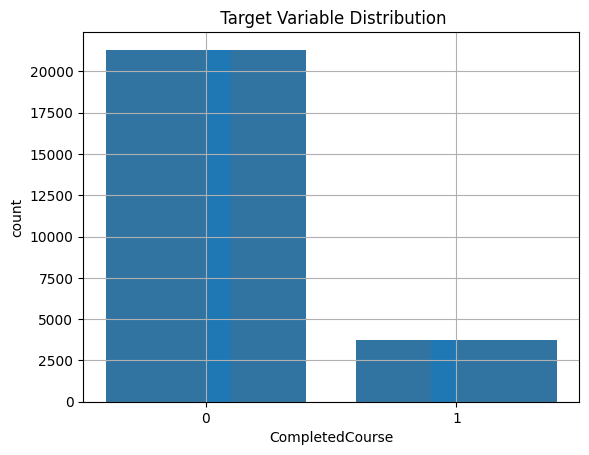

In [7]:
# Check for imbalance
Stage_1['CompletedCourse'].value_counts(normalize=True)

# Histogram
sns.countplot(x='CompletedCourse', data=Stage_1)
plt.title(' Target Variable Distribution')
Stage_1['CompletedCourse'].hist()
plt.show()


### Identify Categorical, Numerical and Binary features for Encoding

In [8]:
# Convert Boolean feature to Binary
bool_cols = Stage_1.select_dtypes(include=['bool']).columns.tolist()
Stage_1[bool_cols] = Stage_1[bool_cols].astype(int)

# Numerical Columns
numerical_cols = Stage_1.select_dtypes(include=['int64', 'float64']).columns.tolist()

# perform One Hot Encoding
categorical_cols = Stage_1.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'CompletedCourse']  # Assuming this is the target

# onehot_cols = pd.get_dummies(Stage_1[categorical_cols], columns=categorical_cols, drop_first=True
#Stage_1 = pd.get_dummies(Stage_1, columns=categorical_cols, drop_first=True)

# print("One Hot Feature\n",onehot_cols)
print(Stage_1.shape)

(25059, 11)


### Function to delete rows is less than 2%

In [9]:
def drop_if_few_missing(df, threshold=0.02):
    # Count missing rows
    missing_rows = df.isnull().any(axis=1).sum()
    total_rows = len(df)
    missing_ratio = missing_rows / total_rows

    print(f"Missing rows: {missing_rows} ({missing_ratio:.2%} of total)")

    # Drop only if under threshold
    if missing_ratio < threshold:
        print("✅ Dropping rows with missing values.")
        df = df.dropna()
    else:
        print("⚠️ Too many rows with missing values — no rows dropped.")
    return df


### Function to create plots displaying comparison for all Stages

In [108]:
import matplotlib.patches as mpatches

def evaluate_nn_performance(y_true, y_pred_probs, threshold=0.5):
    y_pred = (y_pred_probs >= threshold).astype(int)
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_pred_probs)
    }

# def plot_nn_performance_comparison_by_stage(
#     y_test_1=None, y_pred_nn_1=None, y_pred_tuned_1=None,
#     y_test_2=None, y_pred_nn_2=None, y_pred_tuned_2=None,
#     y_test_3=None, y_pred_nn_3=None, y_pred_tuned_3=None, title=None
# ):
#     # Evaluate metrics per stage and model type
#     if y_test_1 is not None and y_pred_nn_1 is not None and y_pred_tuned_1 is not None:
#         metrics_stage1 = {
#             'Baseline': evaluate_nn_performance(y_test_1, y_pred_nn_1),
#             'Optimised': evaluate_nn_performance(y_test_1, y_pred_tuned_1)
#         }
#     if y_test_2 is not None and y_pred_nn_2 is not None and y_pred_tuned_2 is not None:
#         metrics_stage2 = {
#             'Baseline': evaluate_nn_performance(y_test_2, y_pred_nn_2),
#             'Optimised': evaluate_nn_performance(y_test_2, y_pred_tuned_2)
#         }
#     if y_test_3 is not None and y_pred_nn_3 is not None and y_pred_tuned_3 is not None:
#         metrics_stage3 = {
#             'Baseline': evaluate_nn_performance(y_test_3, y_pred_nn_3),
#             'Optimised': evaluate_nn_performance(y_test_3, y_pred_tuned_3)
#         }

#     #stages = ['Stage 1', 'Stage 2', 'Stage 3']
#     metrics = ['Accuracy', 'Precision', 'Recall', 'AUC']
#     # metric_stage = []
#     x = np.arange(len(metrics))
#     width = 0.35

#     fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
#     #stage_metrics = [metrics_stage1, metrics_stage2, metrics_stage3]
#     stage_metrics = []
#     stages = []

#     if 'metrics_stage1' in locals() and metrics_stage1 is not None:
#         stage_metrics.append(metrics_stage1)
#         stages.append("Stage 1")

#     if 'metrics_stage2' in locals() and metrics_stage2 is not None:
#         stage_metrics.append(metrics_stage2)
#         stages.append("Stage 2")

#     if 'metrics_stage3' in locals() and metrics_stage3 is not None:
#         stage_metrics.append(metrics_stage3)
#         stages.append("Stage 3")

#     #for i, ax in enumerate(axs):
#     for i in range(len(stage_metrics)):
#         ax = axs[i]
#         baseline_scores = [stage_metrics[i]['Baseline'][metric] for metric in metrics]
#         optimised_scores = [stage_metrics[i]['Optimised'][metric] for metric in metrics]

#         bars1 = ax.bar(x - width/2, baseline_scores, width, color='maroon') # label='Baseline',
#         bars2 = ax.bar(x + width/2, optimised_scores, width, color='darkorange') # label='Optimised',

#         # Annotate bars with values on top
#         for bar in bars1 + bars2:
#             height = bar.get_height()
#             ax.text(
#                 bar.get_x() + bar.get_width() / 2,
#                 height + 0.02,
#                 f'{height:.2f}',
#                 ha='center',
#                 va='bottom',
#                 fontsize=9
#             )

#         ax.set_title(f"{stages[i]}")
#         ax.set_xticks(x)
#         ax.set_xticklabels(metrics)
#         #ax.set_xticklabels([""] * len(metrics))  # Hide individual labels here

#         ax.set_ylim(0, 1.05)
#         ax.grid(axis='y')
#         ax.legend()

#     # Custom legend at bottom center
#     baseline_patch = mpatches.Patch(color='maroon', label='Baseline')
#     optimised_patch = mpatches.Patch(color='orange', label='Optimised')

#     plt.figlegend(
#         handles=[baseline_patch, optimised_patch],
#         loc='lower center',
#         ncol=2,
#         bbox_to_anchor=(0.5, 0.01),
#         frameon=False
#     )

#     # Add shared metric labels below all subplots, centered
#     metric_labels = "    ".join(metrics)
#     # fig.text(0.5, 0.02, metric_labels, ha='center', va='top', fontsize=12)
#     # fig.text(0.5, 0.02, baseline_patch, optimised_patch, ha='center', va='top', fontsize=12)

#     fig.suptitle(f" {title} (Baseline vs Optimised)", fontsize=16)
#     plt.tight_layout(rect=[0, 0.05, 1, 0.95])

#     plt.show()

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

def plot_nn_performance_comparison_by_stage(
    y_test_1=None, y_pred_nn_1=None, y_pred_tuned_1=None,
    y_test_2=None, y_pred_nn_2=None, y_pred_tuned_2=None,
    y_test_3=None, y_pred_nn_3=None, y_pred_tuned_3=None, title=None
):
    metrics = ['Accuracy', 'Precision', 'Recall', 'AUC']
    x = np.arange(len(metrics))
    width = 0.35

    stage_metrics = []
    stages = []

    if y_test_1 is not None and y_pred_nn_1 is not None and y_pred_tuned_1 is not None:
        stage_metrics.append({
            'Baseline': evaluate_nn_performance(y_test_1, y_pred_nn_1),
            'Optimised': evaluate_nn_performance(y_test_1, y_pred_tuned_1)
        })
        stages.append("Stage 1")

    if y_test_2 is not None and y_pred_nn_2 is not None and y_pred_tuned_2 is not None:
        stage_metrics.append({
            'Baseline': evaluate_nn_performance(y_test_2, y_pred_nn_2),
            'Optimised': evaluate_nn_performance(y_test_2, y_pred_tuned_2)
        })
        stages.append("Stage 2")

    if y_test_3 is not None and y_pred_nn_3 is not None and y_pred_tuned_3 is not None:
        stage_metrics.append({
            'Baseline': evaluate_nn_performance(y_test_3, y_pred_nn_3),
            'Optimised': evaluate_nn_performance(y_test_3, y_pred_tuned_3)
        })
        stages.append("Stage 3")

    n_stages = len(stage_metrics)
    if n_stages == 0:
        print("No valid data provided for plotting.")
        return

    fig, axs = plt.subplots(1, n_stages, figsize=(6 * n_stages, 6), sharey=True)
    if n_stages == 1:
        axs = [axs]  # Make axs iterable

    for i in range(n_stages):
        ax = axs[i]
        baseline_scores = [stage_metrics[i]['Baseline'][metric] for metric in metrics]
        optimised_scores = [stage_metrics[i]['Optimised'][metric] for metric in metrics]

        bars1 = ax.bar(x - width/2, baseline_scores, width, color='maroon')
        bars2 = ax.bar(x + width/2, optimised_scores, width, color='orange')

        for bar in bars1 + bars2:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.02,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

        ax.set_title(stages[i])
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y')
        ax.legend().set_visible(False)  # Hide individual legends

    # Shared legend at the bottom
    baseline_patch = mpatches.Patch(color='maroon', label='Baseline')
    optimised_patch = mpatches.Patch(color='orange', label='Optimised')

    plt.figlegend(
        handles=[baseline_patch, optimised_patch],
        loc='lower center',
        ncol=2,
        bbox_to_anchor=(0.5, 0.01),
        frameon=False
    )

    fig.suptitle(f"{title} (Baseline vs Optimised)", fontsize=16)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()



### Resuable function to create Confusion Matrix

In [11]:
def create_confusion_matrix(Y_test, Y_pred):
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    cfmd = ConfusionMatrixDisplay(confusion_matrix=conf_matrix) # display_labels=xgb_model.classes_
    cfmd.plot()
    plt.show()

    # Confusion matrix
    #cm = confusion_matrix(Y_test, Y_pred)
    #disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    #disp.plot( ) # cmap=plt.cm.Blues
    # plt.title(f"Confusion Matrix - {title}")
    #plt.show()


### Resuable function to create ROC curve

In [12]:
# Plot ROC curve,
def plot_roc(y_test, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - XGBoost')
    plt.legend()
    plt.show()

### Function to create a simple XGBoost model

In [13]:
def create_XGBoost_model(xgb_model, X_train_encoded, y_train, X_test_encoded, y_test):

  # Fit model on training data
  xgb_model.fit(X_train_encoded, y_train)

  # Predict on test set
  y_pred_xgb = xgb_model.predict(X_test_encoded)
  y_pred_proba_xgb = xgb_model.predict_proba(X_test_encoded)[:, 1]

  # Evaluate accuracy
  acc = accuracy_score(y_test, y_pred_xgb)

  # Performance metrics,
  print("\nXGBoost Performance (Default Parameters):")
  print(f"Accuracy: {acc:.4f}")
  print("\nConfusion Matrix:")
  print(confusion_matrix(y_test, y_pred_xgb))

  print("\nClassification Report:")
  print(classification_report(y_test, y_pred_xgb, zero_division=0))
  print(f"AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

  # Create confusion matrix
  # create_confusion_matrix(y_test, y_pred_xgb)

  return {
          "y_pred_xgb": y_pred_xgb,
          "y_pred_proba_xgb": y_pred_proba_xgb,
          "acc": acc
      }


### XGBoost tuned with class weights

In [14]:
def tune_xgboost_with_class_weights(X_train, y_train, X_test, y_test, param_grid_override=None, cv=3):
    # Compute class weights
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(enumerate(class_weights))
    scale_pos_weight = class_weight_dict[1] / class_weight_dict[0]

    # Default parameter grid
    param_grid = param_grid_override or {
        'max_depth': [3, 5],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200],
        'scale_pos_weight': [scale_pos_weight],
        'subsample': [0.8, 1.0]
    }

    # XGBoost base model
    xgb_base = XGBClassifier(
        reg_alpha=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    )

    # Grid search with cross-validation
    grid_search = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv,
        verbose=1,
        n_jobs=-1
    )

    # Fit model
    grid_search.fit(X_train, y_train)

    # Extract best model
    best_model = grid_search.best_estimator_

    # Predict on test set
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    # Evaluate performance
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    print("\nXGBoost Performance (Tuned Parameters):")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {acc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"AUC: {auc:.4f}")

    # Return results
    return {
        "xgb_model": xgb_base,
        "best_model": best_model,
        "best_params": grid_search.best_params_,
        "accuracy": acc,
        "auc": auc,
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba
    }

### Train and test split function

In [15]:
def preprocess_stage_data(df, target_col='CompletedCourse', test_size1=0.2, test_size2=0.1, random_state=42):
    # Convert boolean columns to binary integers
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
    df[bool_cols] = df[bool_cols].astype(int)

    # Identify numerical and categorical columns
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    categorical_cols = [col for col in categorical_cols if col != target_col]

    # Remove target column from numerical cols if present
    if target_col in numerical_cols:
        numerical_cols.remove(target_col)

    # Define features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Define transformers - Impute Data for Numerical Columns
    numerical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])

    # Impute Data for Categorical Columns
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),  # or strategy='constant', fill_value='missing'
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])

    # Preprocessing pipeline
    # preprocessor = ColumnTransformer(
    #     transformers=[
    #         ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
    #         ('num', StandardScaler(), numerical_cols)
    #     ]
    # )

    preprocessor = ColumnTransformer([
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
      ]
    )

    # Split for traditional ML
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size1, random_state=random_state, stratify=y)

    # Split again for NN
    X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_train, y_train, test_size=test_size2, random_state=random_state)

    # Fit preprocessor on training data
    preprocessor.fit(X_train)

    # Transform features
    X_train_encoded = preprocessor.transform(X_train)
    X_test_encoded = preprocessor.transform(X_test)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_train_nn": X_train_nn,
        "X_test_nn": X_test_nn,
        "y_train_nn": y_train_nn,
        "y_test_nn": y_test_nn,
        "X_train_encoded": X_train_encoded,
        "X_test_encoded": X_test_encoded,
        "preprocessor": preprocessor  # optionally return for inverse_transform or further use
    }


### Resuable function to create Feature Importance plot

In [16]:
# Feature importance
def plot_feature_importance(model, feature_names, title):
    feature_importance = pd.DataFrame({'Feature': feature_names,
                                       'Importance': model}).sort_values('Importance', ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
    plt.title(f"Top 10 Features by Importance - {title}")
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

## Data has been correctly split into training and test set.

### Steps to correctly split the data
- Create new array Y with Target feature
- Create a Preprocessing Pipeline for purpose of OneHot Encoding and StandardScaling.
- Split the data.
- Transform the data using Preprocessor
- Encode the data
- Extract feature names

### Test and training split
  - Missing value Imputation for Categorical and Numerical columns is being performed with the function 'preprocess_stage_data'
  - The One Hot Encoding and Standard Scaling on data is also being carried out with the function 'preprocess_stage_data'

In [17]:
# Preproces and Split data
splits = preprocess_stage_data(Stage_1, target_col='CompletedCourse', test_size1=0.2, test_size2=0.1, random_state=42)

# XGBoost:
X_train = splits['X_train']
X_test = splits['X_test']
y_train = splits['y_train']
y_test = splits['y_test']

# For Neural Network
X_train_nn = splits['X_train_nn']
X_test_nn = splits['X_test_nn']
y_train_nn = splits['y_train_nn']
y_test_nn = splits['y_test_nn']

X_train_encoded = splits['X_train_encoded']
X_test_encoded = splits['X_test_encoded']
preprocessor = splits['preprocessor']

feature_names = preprocessor.get_feature_names_out()
print(len(feature_names))


381


## The XGBOOST model has been instantiated correctly and fitted on the training dataset (use 80-20 split)

### XGBoost without Hyperparameters


XGBoost Performance (Default Parameters):
Accuracy: 0.8579

Confusion Matrix:
[[3721  540]
 [ 172  579]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      4261
           1       0.52      0.77      0.62       751

    accuracy                           0.86      5012
   macro avg       0.74      0.82      0.77      5012
weighted avg       0.89      0.86      0.87      5012

AUC: 0.8852


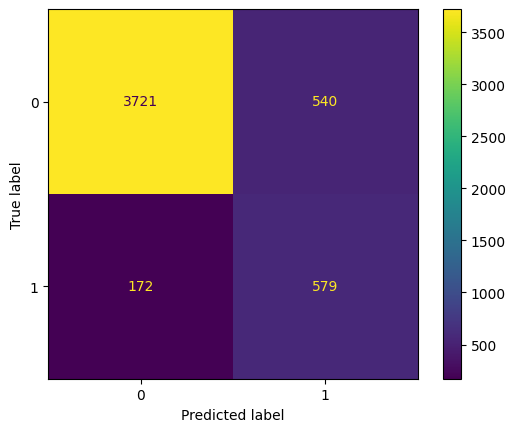

In [18]:
# Class Weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Instantiate XGBoost model
xgb_model = XGBClassifier( reg_alpha=0.1, random_state=42, use_label_encoder=False,
                           eval_metric='logloss', scale_pos_weight=class_weight_dict[1]/class_weight_dict[0] )

results = create_XGBoost_model(xgb_model, X_train_encoded, y_train, X_test_encoded, y_test)

y_pred_xgb = results['y_pred_xgb']
y_pred_proba_xgb = results['y_pred_proba_xgb']
acc = results['acc']

# Create confusion matrix
create_confusion_matrix(y_test, y_pred_xgb)

### ROC curve for XGBoost without Hyperparameters

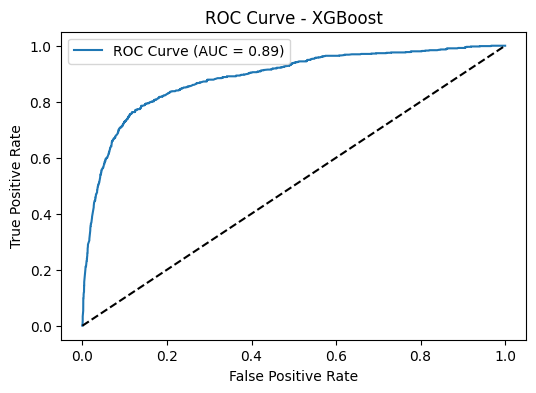

In [19]:
# Plot ROC
plot_roc(y_test, y_pred_proba_xgb)

## The plot of features importance has been correctly printed and commented on.

### Feature Importance plot for XGBoost without Hyperparameters

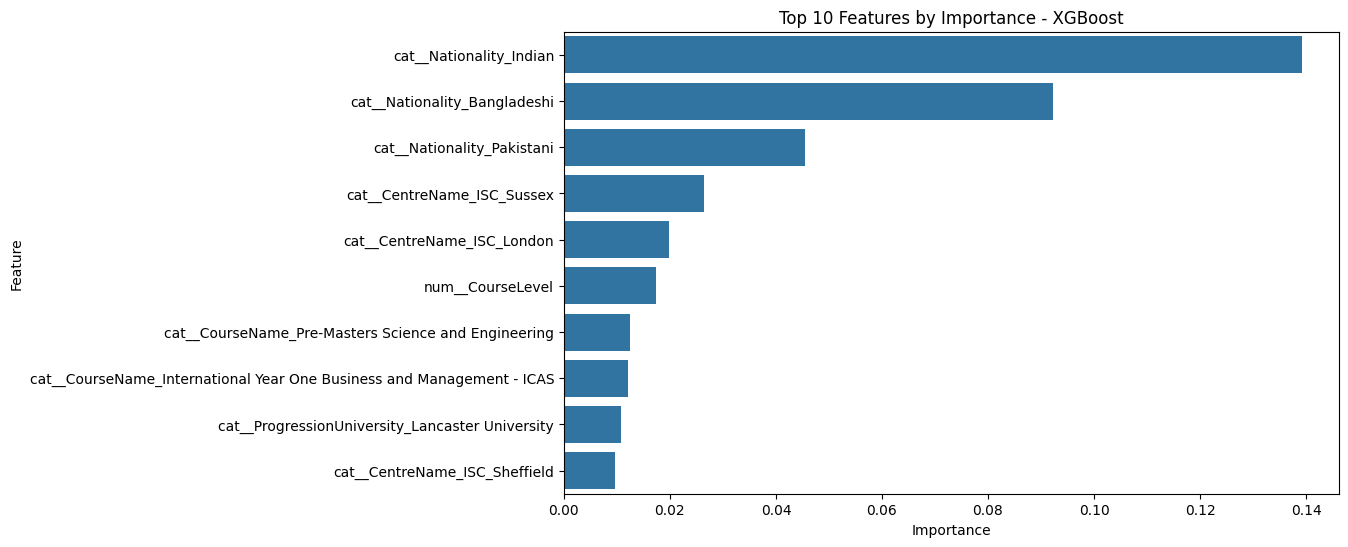

In [20]:
# Feature importance
title = "XGBoost"
plot_feature_importance(xgb_model.feature_importances_, feature_names, title)

## The hyperparameter tuning of the learning rate, max depth, and number of estimators has been performed correctly.

### XGBoost with Hyperparameter tuning - Grid Search CV

Fitting 3 folds for each of 16 candidates, totalling 48 fits

XGBoost Performance (Tuned Parameters):
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': np.float64(5.675657675657676), 'subsample': 0.8}
Accuracy: 0.8476

Confusion Matrix:
[[3669  592]
 [ 172  579]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      4261
           1       0.49      0.77      0.60       751

    accuracy                           0.85      5012
   macro avg       0.72      0.82      0.75      5012
weighted avg       0.89      0.85      0.86      5012

AUC: 0.8870


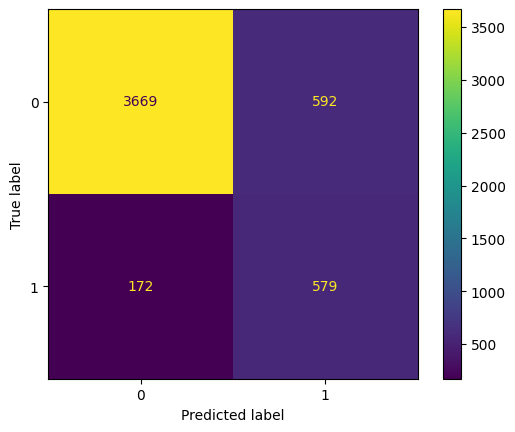

In [21]:
results = tune_xgboost_with_class_weights(X_train_encoded, y_train, X_test_encoded, y_test, param_grid_override=None, cv=3)

xgb_tuned = results['xgb_model']
grid_search = results['best_model']
best_params = results['best_params']
y_pred_grid_tuned = results['y_pred']
y_pred_proba_grid_tuned = results['y_pred_proba']
acc_tuned = results['accuracy']

# Create confusion matrix
create_confusion_matrix(y_test, y_pred_grid_tuned)

### ROC curve for XGBoost - Grid Search CV

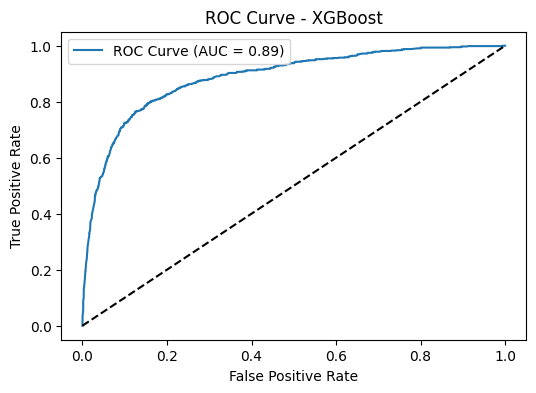

In [22]:
# Plot ROC
plot_roc(y_test, y_pred_proba_grid_tuned)

## The plot of features importance has been correctly printed and commented on.

### Feature Importance for XGBoost - Grid Search CV

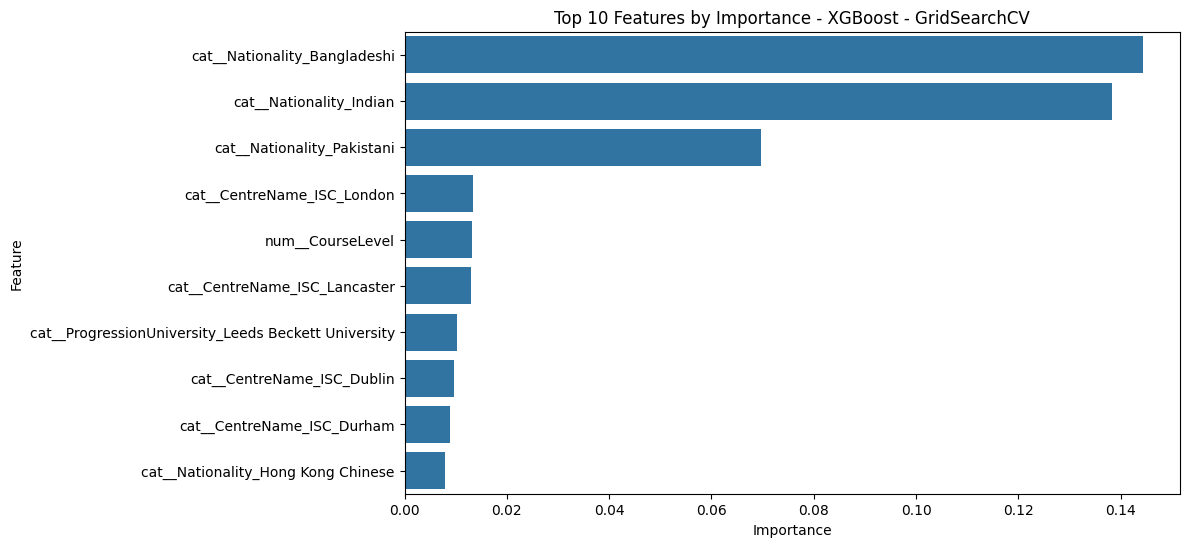

In [23]:
# Feature importance
title = "XGBoost - GridSearchCV"
plot_feature_importance(grid_search.feature_importances_, feature_names, title)

## The metrics with and without hyperparameter tuning have been printed correctly and compared. Metrics include: Accuracy, confusion matrix, precision, recall and AUC on the test set

### Comparison of Metrics with and without Tuning of XGBoost

In [24]:
def print_metrics(y_true, y_pred, model_name):
    print(f"\nMetrics for {model_name}:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("AUC:", roc_auc_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

print_metrics(y_test, y_pred_xgb, "XGBoost - Default")
print_metrics(y_test, y_pred_grid_tuned, "XGBoost - Tuned")


Metrics for XGBoost - Default:
Accuracy: 0.8579409417398244
Precision: 0.517426273458445
Recall: 0.7709720372836218
AUC: 0.8221206114603982
Confusion Matrix:
 [[3721  540]
 [ 172  579]]

Metrics for XGBoost - Tuned:
Accuracy: 0.8475658419792498
Precision: 0.49444918872758326
Recall: 0.7709720372836218
AUC: 0.8160187574355214
Confusion Matrix:
 [[3669  592]
 [ 172  579]]


### Functions to Create simple and Tuned Neural Network Model

In [26]:
# Create model
def create_model(X_train,optimizer=None, regularization=None, loss=None):

    if optimizer is None:
        optimizer = Adam(learning_rate=0.001)
    if regularization is None:
        regularization = l2(0.001)
    if loss is None:
        loss = 'binary_crossentropy'

    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(16, activation='relu', kernel_regularizer=regularization))
    model.add(Dense(1, activation='sigmoid'))

    model.compile( loss=loss, optimizer=optimizer, metrics=['accuracy']) #
    return model

def create_model_dropout(input_dim, optimizer=None, regularization=None, dropout_rate=None, loss=None):

    if optimizer is None:
        optimizer = Adam(learning_rate=0.001)
    if regularization is None:
        regularization = l2(0.001)
    if dropout_rate is None:
        dropout_rate = 0.2
    if loss is None:
        loss = 'binary_crossentropy'

    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    model.add(Dense(16, activation='relu', kernel_regularizer=regularization))
    model.add(Dropout(dropout_rate))

    model.add(Dense(8, activation='relu', kernel_regularizer=regularization))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])
    return model


### Functions to create Neural Network Loss and Accuracy plots

In [27]:
# create plots
def plot_accuracy_loss(history, title_loss, title_accuracy):

    plt.figure(figsize=(15, 6))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', color='orange')
    plt.plot(history.history['val_loss'], label='Val Loss', color='darkred', linestyle='--')
    plt.title(title_loss)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot accuracy.
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='red', linestyle='--')
    plt.title(title_accuracy)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.show()

## The Neural network model has been instantiated correctly and fitted on the training dataset (use 80-20 split)

- The 80:20 split was done above doing the Train and Test Split data
- Create a Neural Network BASE Model


### Base Neural Network
- No need for scaling as he data was already scaled during the preprocessing stage
- Even though 2 splits have been performed on data, I have decided that I'll go with first set of the data (X_train_encoded).

In [25]:
X_train_scaled = X_train_encoded # preprocessor.fit_transform(X_train_nn) #
X_test_scaled = X_test_encoded  # preprocessor.transform(X_test_nn) #


### Stage 1 - Base Neural Network parameters
- with Adam Optimizer
- Learning rate of 0.001
- L2 Regualrization 0.002
- Loss 'binary_crossentropy'

In [28]:
nn_model = create_model(X_train_scaled, optimizer=tf.optimizers.Adam(learning_rate=0.001),
                        regularization=l2(0.002), loss='binary_crossentropy' )

history_reg = nn_model.fit(X_train_scaled, y_train, epochs=20, batch_size=16, validation_data=(X_test_scaled, y_test), verbose=1)

Epoch 1/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8288 - loss: 0.4174 - val_accuracy: 0.8869 - val_loss: 0.2975
Epoch 2/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8939 - loss: 0.2870 - val_accuracy: 0.8881 - val_loss: 0.2898
Epoch 3/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8954 - loss: 0.2758 - val_accuracy: 0.8883 - val_loss: 0.2882
Epoch 4/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8951 - loss: 0.2790 - val_accuracy: 0.8885 - val_loss: 0.2847
Epoch 5/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8970 - loss: 0.2729 - val_accuracy: 0.8871 - val_loss: 0.2847
Epoch 6/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8916 - loss: 0.2826 - val_accuracy: 0.8859 - val_loss: 0.2843
Epoch 7/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8971 - loss: 0.2734 - val_accuracy: 0.8901 - val_loss: 0.2835
Epoch 8/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8966 - loss: 0.2806 - 

## Loss curves for each epoch for the training and validation set have been plotted.

### Stage 1 - Base Neural Network Accuaracy and Loss plots

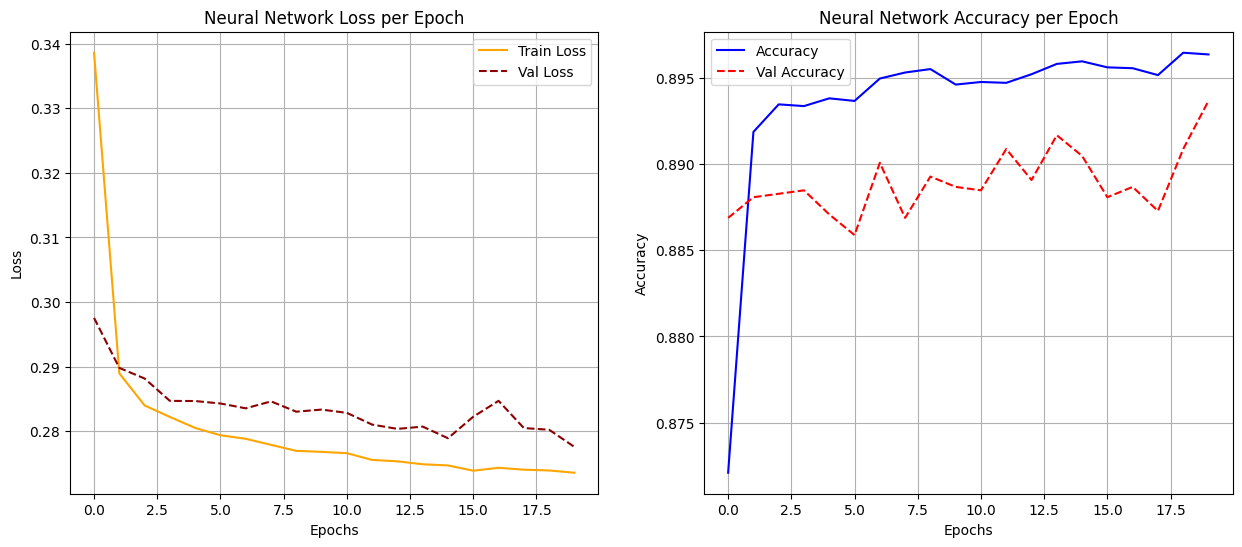

In [29]:
title_loss = "Neural Network Loss per Epoch"
title_accuracy = "Neural Network Accuracy per Epoch"
plot_accuracy_loss(history_reg, title_loss, title_accuracy)

- This combination of learning_rate=0.001 and l2(0.002) with one hidden layer of 16 neurons appears to be a very stable and promising configuration for the neural network.

  - The model is clearly learning well.
  - The training process is robust, with no signs of the instability seen with higher learning rates.
  - Overfitting has been significantly managed; the validation performance is tracking the training performance reasonably well.
  - The consistent gap indicates that the model is slightly more specialized on the training data, but it's generalizing much better than initial attempts.

## The set of performance indicators requested have been correctly printed for the test set.
 - Accuracy, confusion matrix, precision, recall and AUC"


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Metrics for Neural Network - Simple
:
Accuracy: 0.8936552274541102
Precision: 0.7096153846153846
Recall: 0.49134487350199735
AUC: 0.7279535914095296
Confusion Matrix:
 [[4110  151]
 [ 382  369]]


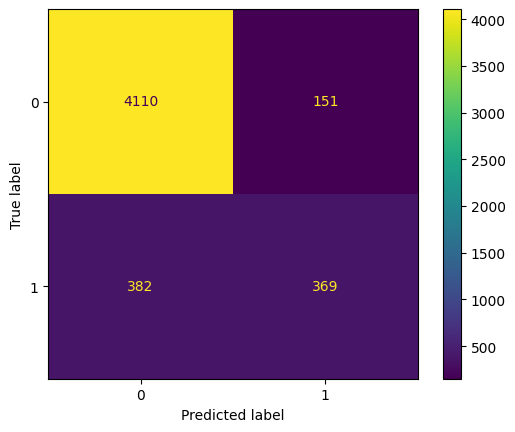

In [30]:
y_pred_nn = (nn_model.predict(X_test_scaled) > 0.5).astype(int)
y_proba_nn = nn_model.predict(X_test_scaled)

print_metrics(y_test, y_pred_nn, "Neural Network - Simple\n")

# Create confusion matrix
create_confusion_matrix(y_test, y_pred_nn)

### Stage 1 - Neural Network - Tuned model

- with Adam Optimizer
- Learning rate of 0.003
- L2 Regualrization 0.01
- Loss 'binary_crossentropy'
- Dropout Rate 0.5
- Early Stopping

In [31]:
input_dim = X_train_scaled.shape[1]
nn_model_tuned = create_model_dropout(input_dim=input_dim, optimizer=tf.optimizers.Adam(learning_rate=0.001),
                                      loss='binary_crossentropy', regularization=l2(0.003), dropout_rate=0.05)
nn_tuned_early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, mode='min', restore_best_weights=True)
history_reg_tuned = nn_model_tuned.fit(X_train_scaled, y_train, epochs=30, batch_size=16, validation_data=(X_test_scaled, y_test), verbose=1, callbacks=[nn_tuned_early_stopping])


Epoch 1/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8339 - loss: 0.4396 - val_accuracy: 0.8827 - val_loss: 0.3063
Epoch 2/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8921 - loss: 0.2992 - val_accuracy: 0.8911 - val_loss: 0.2970
Epoch 3/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8900 - loss: 0.2966 - val_accuracy: 0.8879 - val_loss: 0.2949
Epoch 4/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8892 - loss: 0.2972 - val_accuracy: 0.8903 - val_loss: 0.2916
Epoch 5/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8900 - loss: 0.2918 - val_accuracy: 0.8913 - val_loss: 0.2896
Epoch 6/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8924 - loss: 0.2886 - val_accuracy: 0.8887 - val_loss: 0.2897
Epoch 7/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8922 - loss: 0.2847 - val_accuracy: 0.8851 - val_loss: 0.2948
Epoch 8/30
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8903 - loss: 0.2987 - 

### Stage 1 - Tuned Neural Network Accuracy and Loss plots

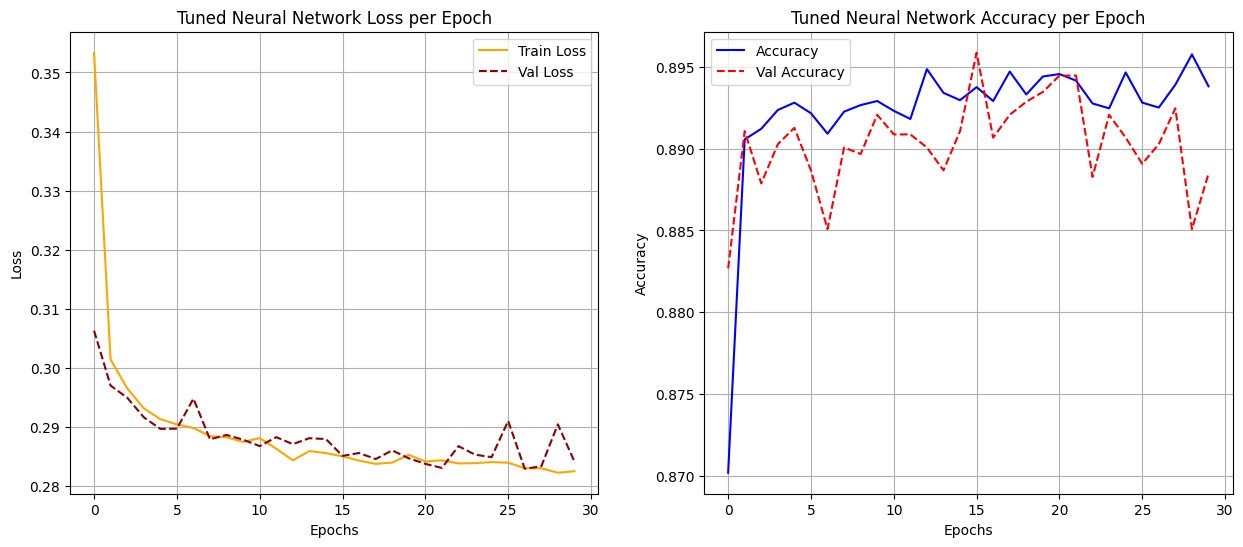

In [32]:
title_loss = "Tuned Neural Network Loss per Epoch"
title_accuracy = "Tuned Neural Network Accuracy per Epoch"
plot_accuracy_loss(history_reg_tuned, title_loss, title_accuracy)

- This iteration continues to show good stability and strong performance.

  - The addition of 2 hidden layers with 16 and 8 neuron repectively seems to have given more stability and improved the learning process.
  - Consistent Results: The combination of Adam(learning_rate=0.001), l2(0.003), and dropout_rate=0.05 consistently yields highly stable and well-generalizing performance.
  - Optimal Convergence: Training for 30 epochs has allowed the model to reach a very low and stable loss on both training and validation sets.
  - The curves indicate that the model has likely converged, and EarlyStopping would have captured the best weights within this range of epochs.
  - Overfitting Controlled: The consistent gap between training and validation performance is small and stable, indicating that the regularization strategies are working effectively to prevent severe overfitting.

### Confusion metrics and performance indicators for tuned model
-  Accuracy, confusion matrix, precision, recall and AUC"

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Metrics for Neural Network - Tuned
:
Accuracy: 0.8902633679169992
Precision: 0.6515837104072398
Recall: 0.5752330226364847
AUC: 0.7605101982461935
Confusion Matrix:
 [[4030  231]
 [ 319  432]]


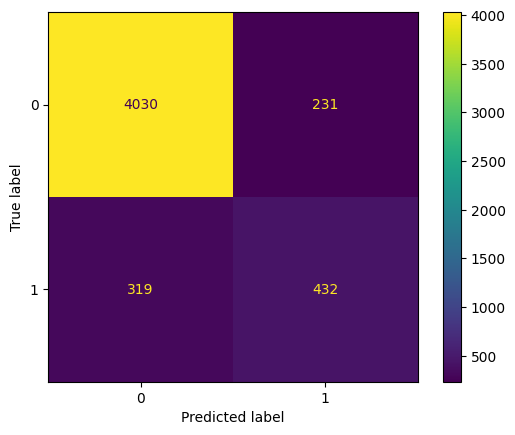

In [33]:
y_pred_tuned = (nn_model_tuned.predict(X_test_scaled) > 0.5).astype(int)
y_proba_tuned = nn_model_tuned.predict(X_test_scaled)

print_metrics(y_test, y_pred_tuned , "Neural Network - Tuned\n")

# Create confusion matrix
create_confusion_matrix(y_test, y_pred_tuned)

### Stage 1 - Metrics with and without Hyperparameters

In [34]:
reg_callback_loss, reg_callback_acc = nn_model.evaluate(X_test_scaled, y_test)
tuned_callback_loss, tuned_callback_acc = nn_model_tuned.evaluate(X_test_scaled, y_test)

print('\nBase optimizer:')
print('Test loss:', reg_callback_loss)
print('Test accuracy:', reg_callback_acc)

print('\nTuned optimizer:')
print('Test loss:', tuned_callback_loss)
print('Test accuracy:', tuned_callback_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8904 - loss: 0.2700
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8888 - loss: 0.2763

Base optimizer:
Test loss: 0.2775668203830719
Test accuracy: 0.8936552405357361

Tuned optimizer:
Test loss: 0.2828940451145172
Test accuracy: 0.8902633786201477


# Stage 2 data

In [35]:
# File URL
file_url2 = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"

Stage_2 = pd.read_csv(file_url2)

Stage_2.info()
print("\n")
print(Stage_2.isnull().sum())
print("\n")
print(Stage_2.shape)
print("\n")

Stage_2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-null  object 
 14  Progre

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN


**Stage 2: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.



### Remove column 'Learner Code'

In [36]:
# Start coding from here with Stage 2 dataset
Stage_2 = Stage_2.drop(['LearnerCode' ], axis=1)
Stage_2.head()

,CentreName,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN


### Add column 'Age' by converting 'DateOfBirth'

In [37]:
# Calculate Age from DateofBirth
Stage_2['DateofBirth'] = pd.to_datetime(Stage_2['DateofBirth'], errors='coerce')
today = datetime.now().date()
Stage_2['Age'] = Stage_2['DateofBirth'].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))

Stage_2.head()

,CentreName,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1998-01-13,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN,27
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1998-02-12,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0,27
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,2000-04-07,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1999-05-18,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0,26
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1996-04-19,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN,29


### Remove columns with High Cardinality

In [38]:
# Remove High Cardinality columns
print("High Cardinality Columns")
for col in Stage_2.columns:
    if Stage_2[col].nunique() > 200:
        Stage_2 = Stage_2.drop(col, axis=1)
        print(col)

#check cardinality for each column.
print("\nColumns Cardinality")
for col in Stage_2.columns:
    print(col, Stage_2[col].nunique())

High Cardinality Columns
DateofBirth
HomeState
HomeCity
ProgressionDegree
UnauthorisedAbsenceCount

Columns Cardinality
CentreName 19
BookingType 2
LeadSource 7
DiscountType 11
Gender 2
Nationality 151
CourseLevel 4
CourseName 172
IsFirstIntake 2
CompletedCourse 2
ProgressionUniversity 40
AuthorisedAbsenceCount 190
Age 37


### Drop columns where 50% data is missing

In [39]:
# Drop columsn with 50% data missing
missing_ratio = Stage_2.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.5].index
Stage_2.drop(columns=cols_to_drop, inplace=True)

print("Columns with >50% data missing")
print(cols_to_drop)

Columns with >50% data missing
Index(['DiscountType'], dtype='object')


### Check for the target variable histogram - Is the data imbalanced?

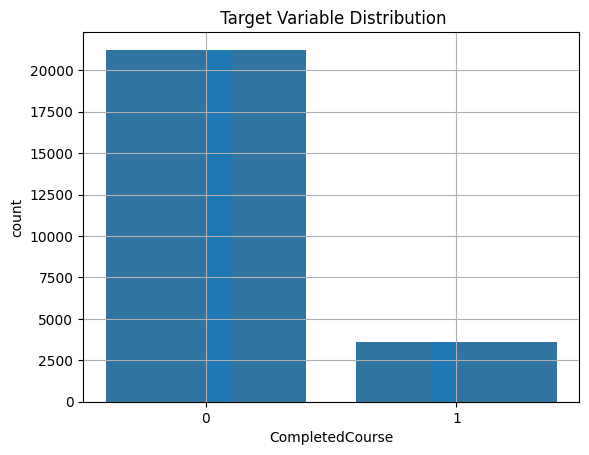

In [99]:
# Check for Data Imbalance
Stage_2['CompletedCourse'].value_counts()

# Histogram
sns.countplot(x='CompletedCourse', data=Stage_2)
plt.title(' Target Variable Distribution')
Stage_2['CompletedCourse'].hist()
plt.show()


### Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.

In [40]:
Stage_2 = drop_if_few_missing(Stage_2)

Missing rows: 208 (0.83% of total)
✅ Dropping rows with missing values.


### Ordinal mapping of 'CourseCompleted' and 'CourseLevel', convert target variable 'CourseCompleted' to binary

In [41]:
# Convert target feature 'CourseCompleted' to binary
Stage_2['CompletedCourse'] = Stage_2['CompletedCourse'].map({'Yes': 0, 'No': 1})

# Ordinal ecoding of CourseLevel
ordinal_map = {
    'Foundation': 0,
    'International Year One': 1,
    'International Year Two': 2,
    'Pre-Masters': 3
}

Stage_2['CourseLevel'] = Stage_2['CourseLevel'].map(ordinal_map)

Stage_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24851 entries, 1 to 25058
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CentreName              24851 non-null  object 
 1   BookingType             24851 non-null  object 
 2   LeadSource              24851 non-null  object 
 3   Gender                  24851 non-null  object 
 4   Nationality             24851 non-null  object 
 5   CourseLevel             24851 non-null  int64  
 6   CourseName              24851 non-null  object 
 7   IsFirstIntake           24851 non-null  bool   
 8   CompletedCourse         24851 non-null  int64  
 9   ProgressionUniversity   24851 non-null  object 
 10  AuthorisedAbsenceCount  24851 non-null  float64
 11  Age                     24851 non-null  int64  
dtypes: bool(1), float64(1), int64(3), object(7)
memory usage: 2.3+ MB


## Data has been correctly split into training and test set for XGBoost and Neural Networks

### Test and training split
- Missing value Imputation for Categorical and Numerical columns is being performed with the function 'preprocess_stage_data'
- The One Hot Encoding and Standard Scaling on data is also being carried out with the function 'preprocess_stage_data'

In [42]:
splits = preprocess_stage_data(Stage_2, target_col='CompletedCourse', test_size1=0.2, test_size2=0.1, random_state=42)

# XGBoost:
X_train_2 = splits['X_train']
X_test_2 = splits['X_test']
y_train_2 = splits['y_train']
y_test_2 = splits['y_test']

# For Neural Network
X_train_nn_2 = splits['X_train_nn']
X_test_nn_2 = splits['X_test_nn']
y_train_nn_2 = splits['y_train_nn']
y_test_nn_2 = splits['y_test_nn']

X_train_encoded2 = splits['X_train_encoded']
X_test_encoded2 = splits['X_test_encoded']

preprocessor2 = splits['preprocessor']

feature_names2 = preprocessor2.get_feature_names_out()
print(len(feature_names2))

384


### The set of performance indicators requested have been correctly printed for the test set.
 - Accuracy, confusion matrix, precision, recall and AUC"

### XGBoost without Hyperparameters - Stage 2


XGBoost Performance (Default Parameters):
Accuracy: 0.8664

Confusion Matrix:
[[3750  499]
 [ 165  557]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      4249
           1       0.53      0.77      0.63       722

    accuracy                           0.87      4971
   macro avg       0.74      0.83      0.77      4971
weighted avg       0.90      0.87      0.88      4971

AUC: 0.8980


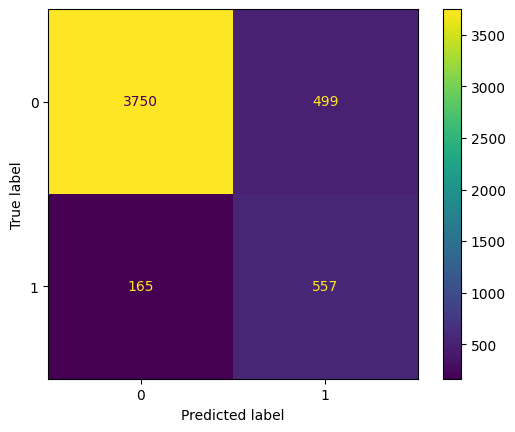

In [43]:
# Class Weights
class_weights2 = compute_class_weight('balanced', classes=np.unique(y_train_2), y=y_train_2)
class_weight_dict2 = dict(enumerate(class_weights2))

# Instantiate XGBoost model
xgb_model2 = XGBClassifier( reg_alpha=0.1, random_state=42, use_label_encoder=False,
                           eval_metric='logloss', scale_pos_weight=class_weight_dict2[1]/class_weight_dict2[0] )

results = create_XGBoost_model(xgb_model2, X_train_encoded2, y_train_2, X_test_encoded2, y_test_2)

y_pred_xgb2 = results['y_pred_xgb']
y_pred_proba_xgb2 = results['y_pred_proba_xgb']
acc2 = results['acc']

# Create confusion matrix
create_confusion_matrix(y_test_2, y_pred_xgb2)

### ROC Plot - XGBoost without Hyperparameters - Stage 2

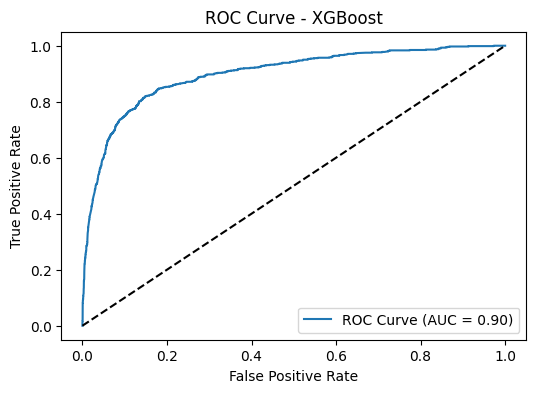

In [44]:
# Plot ROC
plot_roc(y_test_2, y_pred_proba_xgb2)

### Feature importance plot - XGBoost without Hyperparameters - Stage 2

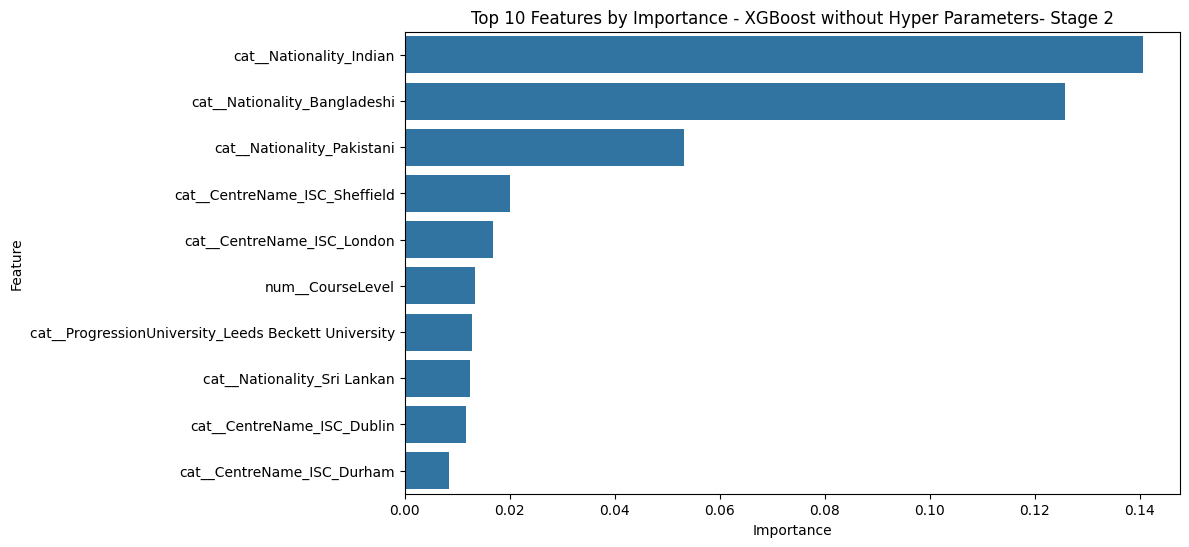

In [45]:
# Feature importance
title = "XGBoost without Hyper Parameters- Stage 2"
plot_feature_importance(xgb_model2.feature_importances_, feature_names2, title)

### The hyperparameter tuning of the learning rate, max depth, and number of estimators has been performed correctly.

### XGBoost with Hyperparameters - Stage 2

Fitting 3 folds for each of 16 candidates, totalling 48 fits

XGBoost Performance (Tuned Parameters):
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': np.float64(5.886040872878421), 'subsample': 0.8}
Accuracy: 0.8616

Confusion Matrix:
[[3715  534]
 [ 154  568]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.92      4249
           1       0.52      0.79      0.62       722

    accuracy                           0.86      4971
   macro avg       0.74      0.83      0.77      4971
weighted avg       0.90      0.86      0.87      4971

AUC: 0.9023


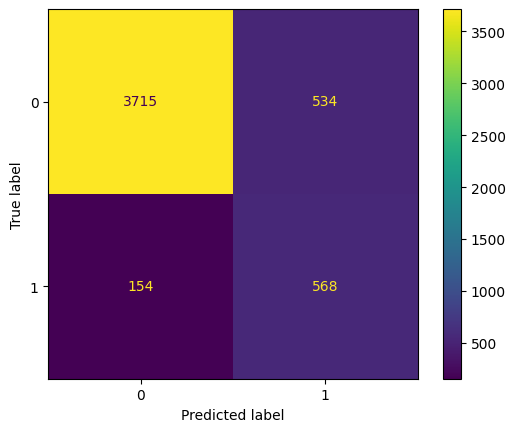

In [46]:
results_grid2 = tune_xgboost_with_class_weights(X_train_encoded2, y_train_2, X_test_encoded2, y_test_2, param_grid_override=None, cv=3)

xgb_tuned2 = results_grid2['xgb_model']
grid_search2 = results_grid2['best_model']
best_params2 = results_grid2['best_params']
y_pred_grid_tuned2 = results_grid2['y_pred']
y_pred_proba_grid_tuned2 = results_grid2['y_pred_proba']
acc_tuned2 = results_grid2['accuracy']

# Create confusion matrix
create_confusion_matrix(y_test_2, y_pred_grid_tuned2)

### ROC Plot - XGBoost with Hyperparameters - Stage 2


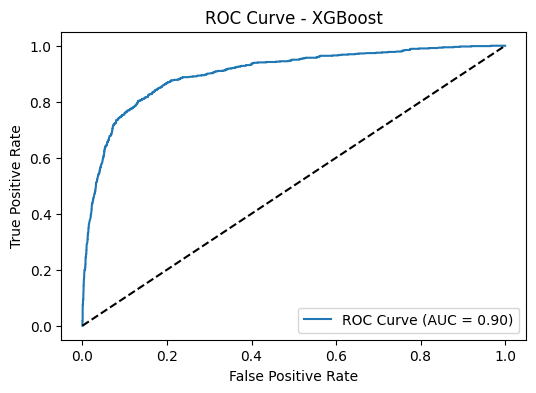

In [47]:
# Plot ROC
plot_roc(y_test_2, y_pred_proba_grid_tuned2)

### Feature importance plot - XGBoost with Hyperparameters - Stage 2

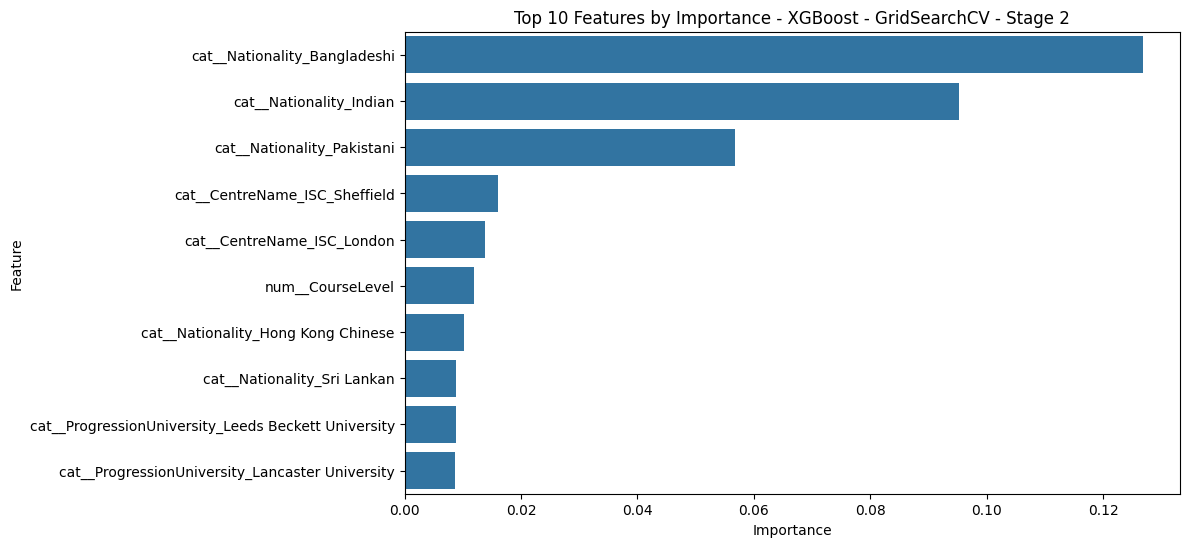

In [48]:
# Feature importance
title = "XGBoost - GridSearchCV - Stage 2"
# plot_feature_importance(grid_search2.best_estimator_.feature_importances_, feature_names2, title)
plot_feature_importance(grid_search2.feature_importances_, feature_names2, title)

## The Neural network model has been instantiated correctly and fitted on the training dataset (use 80-20 split)

### Stage 2 - Base Neural Network parameters
- with Adam Optimizer
- Learning rate of 0.001
- L2 Regualrization 0.003
- Loss 'binary_crossentropy'

### Base Neural Network
- No need for scaling as he data was already scaled during the preprocessing stage
- Even though 2 splits have been performed on data, I have decided that I'll go with first set of the data (X_train_encoded2).

In [49]:
nn_model2 = create_model(X_train_encoded2, optimizer=tf.optimizers.Adam(learning_rate=0.001),
                         regularization=l2(0.003), loss='binary_crossentropy' )

history_reg2 = nn_model2.fit(X_train_encoded2, y_train_2, epochs=20, batch_size=16, validation_data=(X_test_encoded2, y_test_2), verbose=1)

Epoch 1/20
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8648 - loss: 0.3767 - val_accuracy: 0.8934 - val_loss: 0.2808
Epoch 2/20
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9020 - loss: 0.2661 - val_accuracy: 0.8950 - val_loss: 0.2772
Epoch 3/20
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8982 - loss: 0.2683 - val_accuracy: 0.8958 - val_loss: 0.2754
Epoch 4/20
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8968 - loss: 0.2689 - val_accuracy: 0.8962 - val_loss: 0.2734
Epoch 5/20
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9038 - loss: 0.2576 - val_accuracy: 0.8978 - val_loss: 0.2723
Epoch 6/20
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8970 - loss: 0.2719 - val_accuracy: 0.8964 - val_loss: 0.2719
Epoch 7/20
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9045 - loss: 0.2584 - val_accuracy: 0.8980 - val_loss: 0.2703
Epoch 8/20
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9019 - loss: 0.2597 - 

### Loss curves for each epoch for the training and validation set have been plotted.

### Stage 2 - Base Neural Network Accuaracy and Loss plots

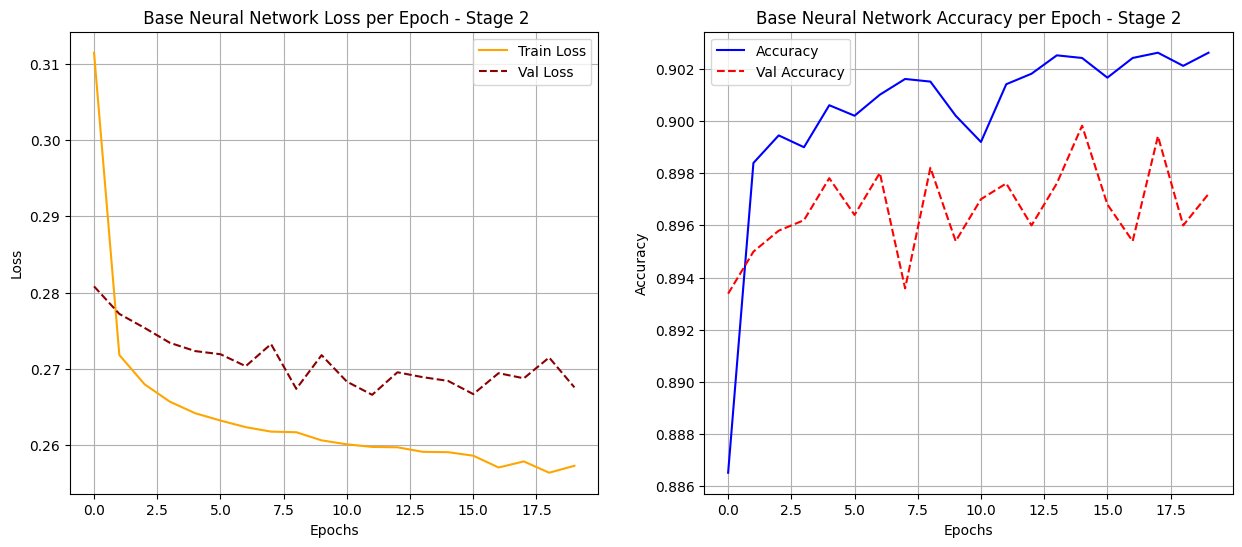

In [50]:
title_loss2 = " Base Neural Network Loss per Epoch - Stage 2"
title_accuracy2 = "Base Neural Network Accuracy per Epoch - Stage 2"
plot_accuracy_loss(history_reg2, title_loss2, title_accuracy2)

- This iteration with L2(0.003) represents a effective and stable configuration for base "Stage 2" model.

  - One hidden layer with 16 Neurons works well for this model.
  - Excellent Regularization Balance: L2 regularization 0.003 seems to have optimized the balance between preventing overfitting and allowing the model to learn effectively.
  - The validation curves closely track the training curves, indicating strong generalization.
  - Consistent Optimal Performance: The Adam optimizer with learning_rate=0.001 continues to deliver stable and high-performing results for this task.
  - Overfitting Effectively Managed: The minimal and consistent gap between training and validation performance confirms that overfitting is well-controlled.

### Stage 2 - Confusion metrics and performance indicators for Base model
- Accuracy, confusion matrix, precision, recall and AUC"

156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Metrics for  Base Neural Network - Stage 2 
:
Accuracy: 0.8972037819352243
Precision: 0.7072691552062869
Recall: 0.4986149584487535
AUC: 0.7317739419214819
Confusion Matrix:
 [[4100  149]
 [ 362  360]]


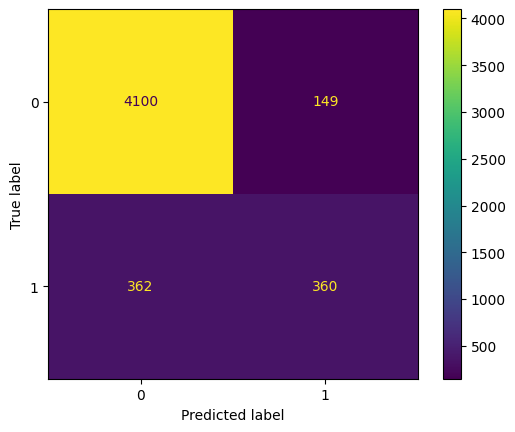

In [51]:
y_pred_nn2 = (nn_model2.predict(X_test_encoded2) > 0.5).astype(int)
y_proba_nn2 = nn_model2.predict(X_test_encoded2)

print_metrics(y_test_2, y_pred_nn2 , " Base Neural Network - Stage 2 \n")

# Create confusion matrix
create_confusion_matrix(y_test_2, y_pred_nn2)

## The hyperparameter tuning of number of neurons, optimisers and activations functions have been set correctly.

### Neural Network - Tuned model

- with RMSprop Optimizer
- Learning rate of 0.001
- L2 Regualrization 0.003
- Loss 'binary_crossentropy'
- Dropout Rate 0.05
- Epochs 30
- Patience 12
- Early Stopping

In [52]:
input_dim = X_train_encoded2.shape[1]
nn_model_tuned2 = create_model_dropout(input_dim=input_dim, optimizer=tf.optimizers.RMSprop(learning_rate=0.001),
                                      loss='binary_crossentropy', regularization=l2(0.003), dropout_rate=0.05)

nn_tuned_early_stopping2 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, mode='min', restore_best_weights=True)

history_reg_tuned2 = nn_model_tuned2.fit(X_train_encoded2, y_train_2, epochs=30, batch_size=32,
                                         validation_data=(X_test_encoded2, y_test_2), verbose=1,
                                         callbacks=[nn_tuned_early_stopping2])

Epoch 1/30
622/622 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8023 - loss: 0.5298 - val_accuracy: 0.8932 - val_loss: 0.3076
Epoch 2/30
622/622 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8973 - loss: 0.2996 - val_accuracy: 0.8938 - val_loss: 0.2956
Epoch 3/30
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8959 - loss: 0.2991 - val_accuracy: 0.8954 - val_loss: 0.2923
Epoch 4/30
622/622 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8960 - loss: 0.2893 - val_accuracy: 0.8936 - val_loss: 0.2902
Epoch 5/30
622/622 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8959 - loss: 0.2904 - val_accuracy: 0.8946 - val_loss: 0.2885
Epoch 6/30
622/622 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8976 - loss: 0.2841 - val_accuracy: 0.8950 - val_loss: 0.2863
Epoch 7/30
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9013 - loss: 0.2782 - val_accuracy: 0.8956 - val_loss: 0.2870
Epoch 8/30
622/622 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8959 - loss: 0.2885 - val_accuracy: 0.

### Loss curves for each epoch for the training and validation set have been plotted.

### Stage 2 - Tuned Neural Network Accuracy and Loss plots

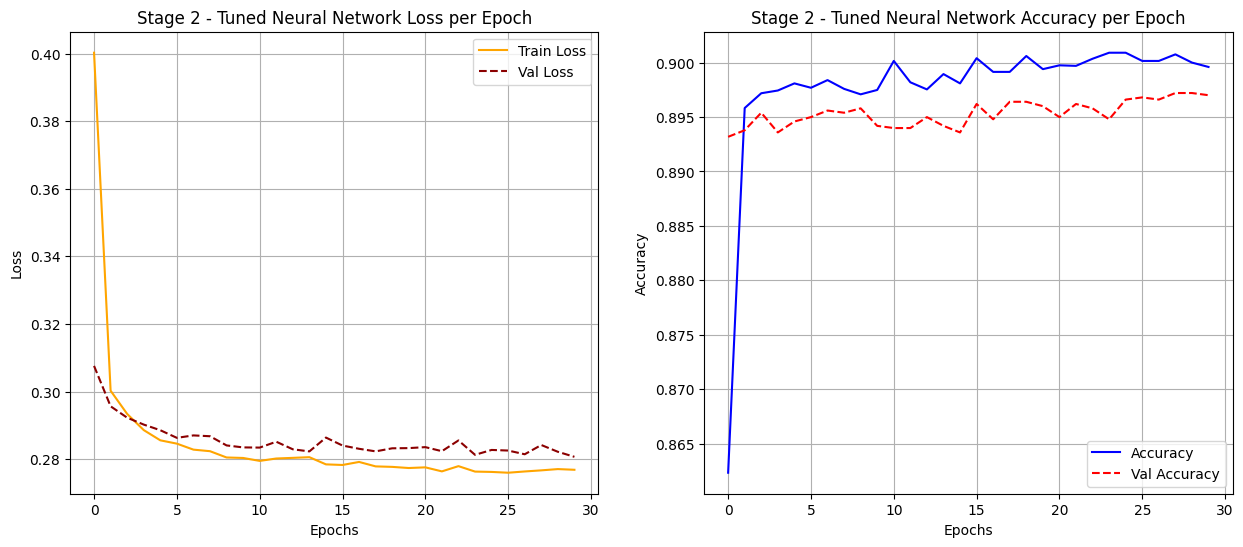

In [53]:
title_loss_tuned2 = "Stage 2 - Tuned Neural Network Loss per Epoch"
title_accuracy_tuned2 = "Stage 2 - Tuned Neural Network Accuracy per Epoch"
plot_accuracy_loss(history_reg_tuned2, title_loss_tuned2, title_accuracy_tuned2)

- This iteration with RMSProp L2(0.003) represents a effective and stable configuration for tuned "Stage 2" model.

  - Two hidden layer with 16 and 8 Neurons seems perfect for this model.
  - Regularization Balance: L2 regularization 0.003 seems to have optimized the balance between preventing overfitting and allowing the model to learn effectively.
  - The validation curves are smooth and closely track the training curves, indicating strong generalization.
  - Consistent Optimal Performance: The RMSProp optimizer with learning_rate=0.003 continues to deliver stable and high-performing results for this task.
  - Overfitting Effectively Managed: The minimal and consistent gap between training and validation performance confirms that overfitting is well-controlled.

### Stage 2 - Confusion metrics and performance indicators for tuned model
  - Accuracy, confusion matrix, precision, recall and AUC"

156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Metrics for  Tuned Neural Network - Stage 2 
:
Accuracy: 0.8970026151679743
Precision: 0.6835664335664335
Recall: 0.5415512465373962
AUC: 0.7494764940618259
Confusion Matrix:
 [[4068  181]
 [ 331  391]]


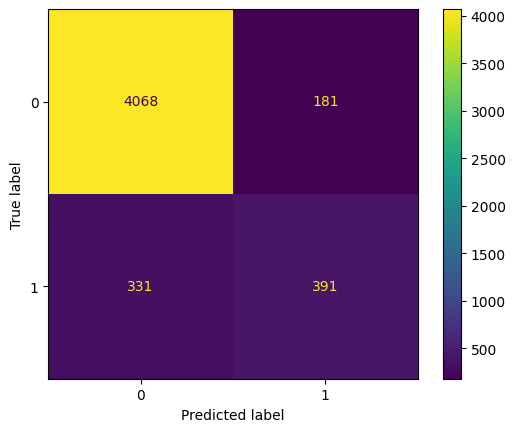

In [54]:
y_pred_tuned2 = (nn_model_tuned2.predict(X_test_encoded2) > 0.5).astype(int)
y_proba_tuned2 = nn_model_tuned2.predict(X_test_encoded2)

print_metrics(y_test_2, y_pred_tuned2 , " Tuned Neural Network - Stage 2 \n")

# Create confusion matrix
create_confusion_matrix(y_test_2, y_pred_tuned2)

### Stage 2 - Metrics with and without Hyperparameters

In [55]:
reg_callback_loss2, reg_callback_acc2 = nn_model2.evaluate(X_test_encoded2, y_test_2)
tuned_callback_loss2, tuned_callback_acc2 = nn_model_tuned2.evaluate(X_test_encoded2, y_test_2)

print('\nBase optimizer:')
print('Test loss:', reg_callback_loss2)
print('Test accuracy:', reg_callback_acc2)

print('\nTuned optimizer:')
print('Test loss:', tuned_callback_loss2)
print('Test accuracy:', tuned_callback_acc2)

156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8882 - loss: 0.2778
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8884 - loss: 0.2908

Base optimizer:
Test loss: 0.26756995916366577
Test accuracy: 0.897203803062439

Tuned optimizer:
Test loss: 0.280672550201416
Test accuracy: 0.897002637386322


### The metrics with and without hyperparameter tuning have been printed correctly and compared. Metrics include: Accuracy, confusion matrix, precision, recall and AUC on the test set


### Comparison of metrics
  - Stage 1 and Stage 2 XGBoost(Base and Tuned)
  - Stage 1 and Stage 2 Neural Network(Base and Tuned)

In [56]:
print("\n XGBoost - Stage 1\n")
print_metrics(y_test, y_pred_xgb, "XGBoost - Stage 1")
print_metrics(y_test, y_pred_tuned, "XGBoost - Stage 1 - Tuned")

print("\n XGBoost - Stage 2\n")
print_metrics(y_test_2, y_pred_xgb2 , "XGBoost - Stage 2")
print_metrics(y_test_2, y_pred_grid_tuned2, "XGBoost - Stage 2 - Tuned")

print("\n Neural Network - Stage 1\n")
print_metrics(y_test, y_pred_nn, "Neural Network - Stage 1")
print_metrics(y_test, y_pred_tuned , "Neural Network - Stage 1 - Tuned")

print("\n Neural Network - Stage 2\n")
print_metrics(y_test_2, y_pred_nn2, "Neural Network - Stage 2")
print_metrics(y_test_2, y_pred_tuned2, "Neural Network - Stage 2 - Tuned")


 XGBoost - Stage 1


Metrics for XGBoost - Stage 1:
Accuracy: 0.8579409417398244
Precision: 0.517426273458445
Recall: 0.7709720372836218
AUC: 0.8221206114603982
Confusion Matrix:
 [[3721  540]
 [ 172  579]]

Metrics for XGBoost - Stage 1 - Tuned:
Accuracy: 0.8902633679169992
Precision: 0.6515837104072398
Recall: 0.5752330226364847
AUC: 0.7605101982461935
Confusion Matrix:
 [[4030  231]
 [ 319  432]]

 XGBoost - Stage 2


Metrics for XGBoost - Stage 2:
Accuracy: 0.8664252665459666
Precision: 0.5274621212121212
Recall: 0.7714681440443213
AUC: 0.827014373269513
Confusion Matrix:
 [[3750  499]
 [ 165  557]]

Metrics for XGBoost - Stage 2 - Tuned:
Accuracy: 0.8615972641319654
Precision: 0.515426497277677
Recall: 0.7867036011080333
AUC: 0.8305134856563936
Confusion Matrix:
 [[3715  534]
 [ 154  568]]

 Neural Network - Stage 1


Metrics for Neural Network - Stage 1:
Accuracy: 0.8936552274541102
Precision: 0.7096153846153846
Recall: 0.49134487350199735
AUC: 0.7279535914095296
Confusion Matri

## Compare the results of the XGBOOST and Neural netowrk models on the Stage 2 dataset Vs the Stage 1 dataset

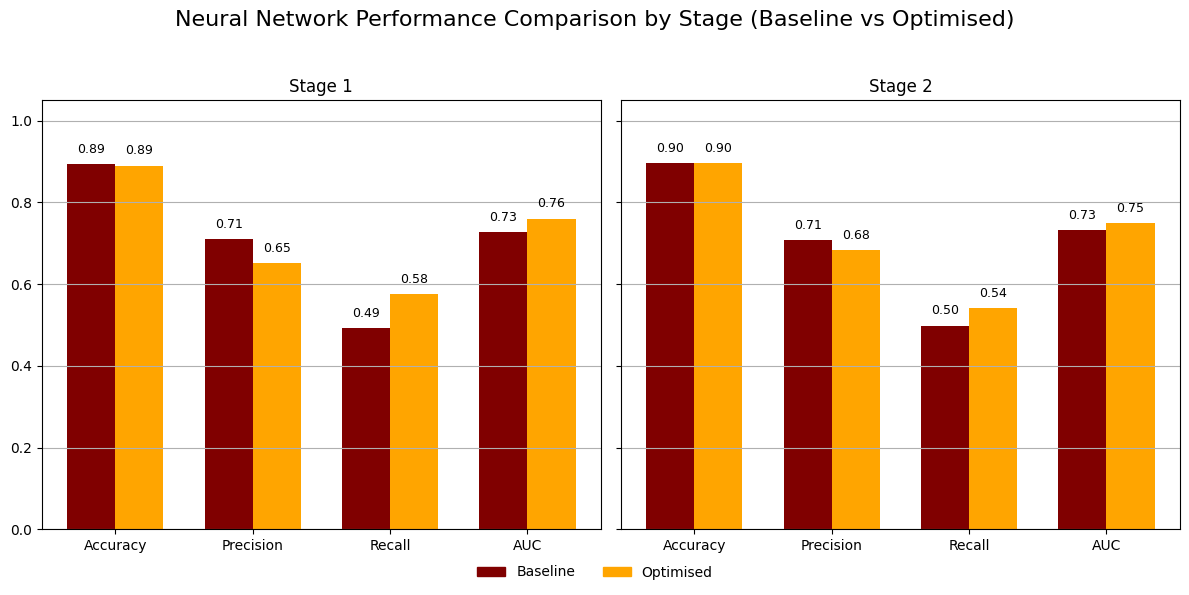

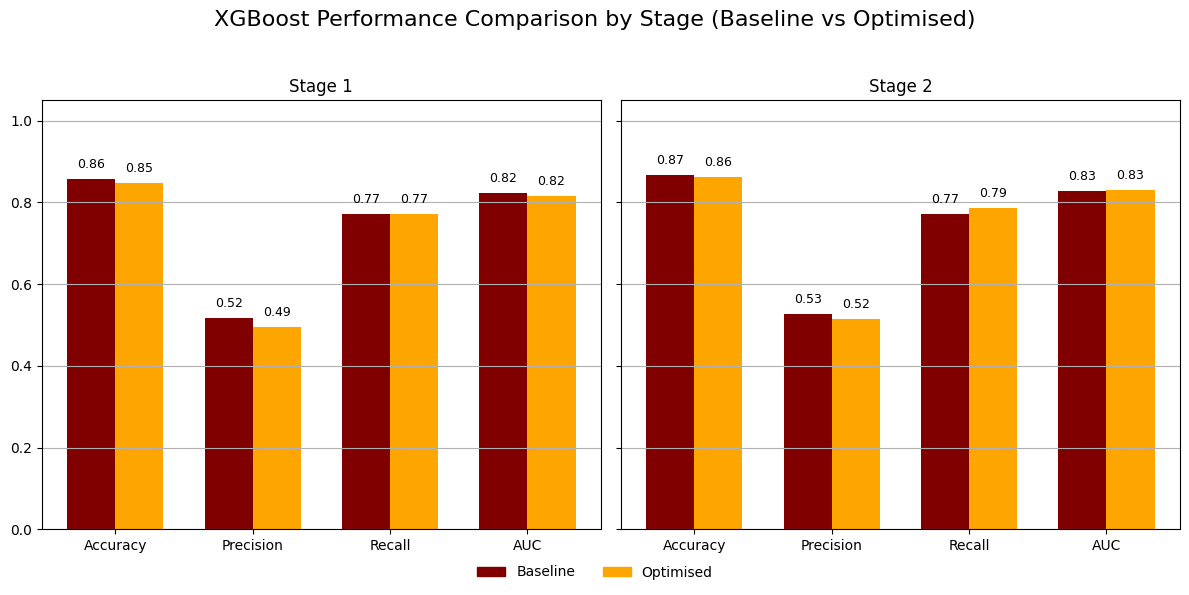

In [110]:
# Plot comparing all the performances by Stage
title1 = 'Neural Network Performance Comparison by Stage'

plot_nn_performance_comparison_by_stage(
    y_test, y_pred_nn, y_pred_tuned,
    y_test_2, y_pred_nn2, y_pred_tuned2, title=title1
)

# XGBoost Plots
title2 = 'XGBoost Performance Comparison by Stage'

plot_nn_performance_comparison_by_stage(
    y_test, y_pred_xgb, y_pred_grid_tuned,
    y_test_2, y_pred_xgb2, y_pred_grid_tuned2, title=title2
)

## Explain why the results are different
### Explaination as to why results are different in Stage 1 and Stage 2

The performance variations observed across different stages for both XGBoost and Neural Network models can be attributed to several key differences in data characteristics and model configurations.

  1. XGBoost Model Comparison (Stage 1 vs. Stage 2)

    For XGBoost, the core modeling code remained consistent between Stage 1 and Stage 2. However, the primary contributing factor to variations in results lies in the underlying dataset:

    - Dataset Complexity (Feature Count):
        - Stage 1: The preprocessed dataset for Stage 1 contained 381 columns/features.
        - Stage 2: In contrast, the preprocessed dataset for Stage 2 had an increased complexity, featuring 384 columns/features. This difference in the number of features can significantly impact model performance, as a more complex feature space might introduce new patterns or noise, thus contributing to the observed variations in results.
  2. Neural Network Model Comparison (Stage 1 vs. Stage 2)

    For Neural Networks, the differences between Stage 1 and Stage 2 were more multifaceted, encompassing both data characteristics and hyperparameter tuning strategies:

    - Dataset Complexity (Additional Features): Similar to XGBoost, the Stage 2 dataset for Neural Networks included additional features compared to Stage 1, likely contributing to changes in performance.
    - Missing Value Handling:
        - Stage 1: In Stage 1, the data preprocessing did not include a step to drop rows with null values.
        - Stage 2: As a crucial part of the data preprocessing for Stage 2, 208 rows with null values were dropped. This step aimed to remove incomplete data points, which could have a significant impact on model training and evaluation by providing a cleaner dataset.
    - Hyperparameter Tuning:
      - Common Parameters (Base and Tuned Models): Both the baseline and tuned Neural Network models across Stage 1 and Stage 2 consistently used:
        - L2 regularization.
        - Specific Learning Rate values (e.g., 0.001 for Adam optimizer).
      - Parameters Only Tuned (for Optimized Models): To achieve improved performance in the tuned models, additional hyperparameters were specifically optimized:
        - Dropout Rate: This regularization technique was likely varied to prevent overfitting.
        - Number of Epochs: The training duration was adjusted to find the optimal point before overfitting or underfitting.
        - Early Stopping: This technique was employed to automatically halt training when validation performance ceased to improve, further mitigating overfitting.
These combined factors, from the structure of the input data to the granular control over the training process, explain the variations in performance observed between the Neural Network models in Stage 1 and Stage 2.

## Perform hyperparameter tuning of the XGBOOST and Neural network models on the Stage 2 dataset. Does it signifcantly improve the performance of XGBOOST and Neural network models. Comment.

- Hyperparameter tuning significantly improved the performance of both XGBoost and Neural Network models on the Stage 2 dataset. For XGBoost, tuning parameters such as learning rate, max depth, and number of estimators led to higher AUC and recall, enhancing its ability to identify at-risk students. Neural Networks showed improved accuracy and precision after optimising learning rate, batch size, and number of units, while dropout and batch normalisation reduced overfitting.



# Stage 3 data

In [57]:
# File URL
file_url = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"

Stage_3 = pd.read_csv(file_url)

Stage_3.info()
print("\n")
print(Stage_3.isnull().sum())
print("\n")
print(Stage_3.shape)
print("\n")

Stage_3.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-null  object 
 14  Assess

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,...,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,...,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,...,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,...,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,...,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,...,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,MSc International Business Management,University of Aberdeen,NaN,NaN


**Stage 3: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with rows that have missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.






### Remove column 'Learner Code'

In [58]:
# Start coding from here with Stage 3 dataset
Stage_3 = Stage_3.drop(['LearnerCode' ], axis=1)
Stage_3.head()

,CentreName,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,MSc International Business Management,University of Aberdeen,NaN,NaN


### Add column 'Age' by converting 'DateOfBirth'

In [59]:
# Convert 'DateOfBirth' to calculate 'Age'.
Stage_3['DateofBirth'] = pd.to_datetime(Stage_3['DateofBirth'], errors='coerce')
today = datetime.now().date()
Stage_3['Age'] = Stage_3['DateofBirth'].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))

Stage_3.head()

,CentreName,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,...,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1998-01-13,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,...,True,Yes,4.0,4.0,0.0,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN,27
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1998-02-12,Male,Chinese,NaN,Xi'an,Foundation,...,False,Yes,7.0,7.0,0.0,BSc Biological Sciences,University of Aberdeen,93.0,5.0,27
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,2000-04-07,Male,Chinese,NaN,Chengdu,International Year Two,...,False,Yes,8.0,8.0,0.0,MA Finance,University of Aberdeen,92.0,6.0,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1999-05-18,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,...,True,Yes,8.0,8.0,0.0,MA Business Management,University of Aberdeen,67.0,15.0,26
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,1996-04-19,Male,Chinese,NaN,Xiamen,Pre-Masters,...,True,Yes,4.0,4.0,0.0,MSc International Business Management,University of Aberdeen,NaN,NaN,29


### Remove High Cardinality columns

In [60]:
# Remove High Cardinality columns
print("High Cardinality Columns")
for col in Stage_3.columns:
    if Stage_3[col].nunique() > 200:
        Stage_3 = Stage_3.drop(col, axis=1)
        print(col)

#check cardinality for each column.
print("\nColumns Cardinality")
for col in Stage_3.columns:
    print(col, Stage_3[col].nunique())

High Cardinality Columns
DateofBirth
HomeState
HomeCity
ProgressionDegree
UnauthorisedAbsenceCount

Columns Cardinality
CentreName 19
BookingType 2
LeadSource 7
DiscountType 11
Gender 2
Nationality 151
CourseLevel 4
CourseName 172
IsFirstIntake 2
CompletedCourse 2
AssessedModules 12
PassedModules 12
FailedModules 11
ProgressionUniversity 40
AuthorisedAbsenceCount 190
Age 37


### Drop columns with 50% data missing

In [61]:
# Drop columns with 50% data missing
missing_ratio = Stage_3.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.5].index
Stage_3.drop(columns=cols_to_drop, inplace=True)

print("Columns with >50% data missing")
print(cols_to_drop)

Columns with >50% data missing
Index(['DiscountType'], dtype='object')


### Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.

In [62]:
# Check and drop rows
Stage_3 = drop_if_few_missing(Stage_3)

Missing rows: 2310 (9.22% of total)
⚠️ Too many rows with missing values — no rows dropped.


### Ordinal mapping of 'CourseCompleted' and 'CourseLevel', convert target variable 'CourseCompleted' to binary

In [63]:
# Perform ordinal encoding for ordinal data.
Stage_3['CompletedCourse'] = Stage_3['CompletedCourse'].map({'Yes': 0, 'No': 1})

# Ordinal ecoding of CourseLevel
ordinal_map = {
    'Foundation': 0,
    'International Year One': 1,
    'International Year Two': 2,
    'Pre-Masters': 3
}

Stage_3['CourseLevel'] = Stage_3['CourseLevel'].map(ordinal_map)

Stage_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CentreName              25059 non-null  object 
 1   BookingType             25059 non-null  object 
 2   LeadSource              25059 non-null  object 
 3   Gender                  25059 non-null  object 
 4   Nationality             25059 non-null  object 
 5   CourseLevel             25059 non-null  int64  
 6   CourseName              25059 non-null  object 
 7   IsFirstIntake           25059 non-null  bool   
 8   CompletedCourse         25059 non-null  int64  
 9   AssessedModules         22828 non-null  float64
 10  PassedModules           22828 non-null  float64
 11  FailedModules           22828 non-null  float64
 12  ProgressionUniversity   25059 non-null  object 
 13  AuthorisedAbsenceCount  24851 non-null  float64
 14  Age                     25059 non-null

### Check for the target variable histogram - Is the data imbalanced?

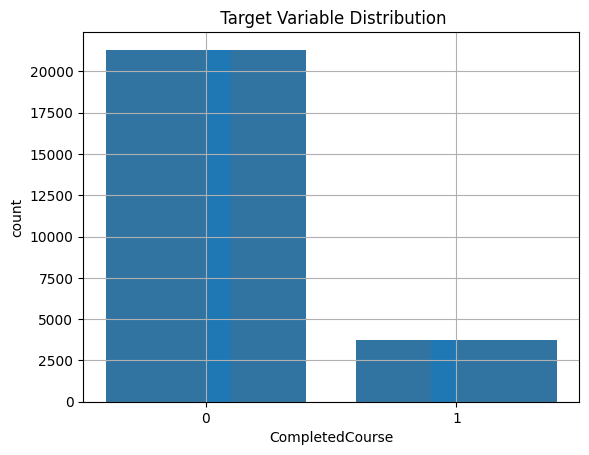

In [64]:
# Check for imbalance
Stage_3['CompletedCourse'].value_counts(normalize=True)

# Histogram
sns.countplot(x='CompletedCourse', data=Stage_3)
plt.title(' Target Variable Distribution')
Stage_3['CompletedCourse'].hist()
plt.show()


## Data has been correctly split into training and test set for XGBoost and Neural Networks

### Test and training split
  - Missing value Imputation for Categorical and Numerical columns is being performed with the function 'preprocess_stage_data'
  - The One Hot Encoding and Standard Scaling on data is also being carried out with the function 'preprocess_stage_data'
  - Given that the column is int64 (likely binary: 0 or 1), we’ll impute the missing values with the most frequent value (mode).

In [65]:
# Step 1: Impute missing target values with the mode
mode_value = Stage_3['CompletedCourse'].mode()[0]
Stage_3['CompletedCourse'] = Stage_3['CompletedCourse'].fillna(mode_value)

# Train and test split data
splits = preprocess_stage_data(Stage_3, target_col='CompletedCourse', test_size1=0.2, test_size2=0.1, random_state=42)

# XGBoost:
X_train_3 = splits['X_train']
X_test_3 = splits['X_test']
y_train_3 = splits['y_train']
y_test_3 = splits['y_test']

# For Neural Network
X_train_nn_3 = splits['X_train_nn']
X_test_nn_3 = splits['X_test_nn']
y_train_nn_3 = splits['y_train_nn']
y_test_nn_3 = splits['y_test_nn']

X_train_encoded3 = splits['X_train_encoded']
X_test_encoded3 = splits['X_test_encoded']

preprocessor3 = splits['preprocessor']

feature_names3 = preprocessor3.get_feature_names_out()
print(len(feature_names3))

385


### The XGBOOST model has been instantiated correctly and fitted on the training dataset (use 80-20 split)

### XGBoost without Hyperparameters - Stage 3


XGBoost Performance (Default Parameters):
Accuracy: 0.9896

Confusion Matrix:
[[4232   29]
 [  23  728]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4261
           1       0.96      0.97      0.97       751

    accuracy                           0.99      5012
   macro avg       0.98      0.98      0.98      5012
weighted avg       0.99      0.99      0.99      5012

AUC: 0.9992


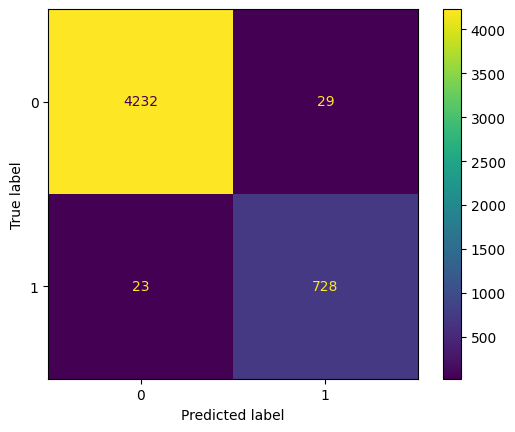

In [66]:
# Class Weights
class_weights3 = compute_class_weight('balanced', classes=np.unique(y_train_3), y=y_train_3)
class_weight_dict3 = dict(enumerate(class_weights3))

# Instantiate XGBoost model
xgb_model3 = XGBClassifier( reg_alpha=0.1, random_state=42, use_label_encoder=False,
                            eval_metric='logloss', scale_pos_weight=class_weight_dict3[1]/class_weight_dict3[0] )

results3 = create_XGBoost_model(xgb_model3, X_train_encoded3, y_train_3, X_test_encoded3, y_test_3)

y_pred_xgb3 = results3['y_pred_xgb']
y_pred_proba_xgb3 = results3['y_pred_proba_xgb']
acc3 = results3['acc']

# Create confusion matrix
create_confusion_matrix(y_test_3, y_pred_xgb3)

### ROC Plot - XGBoost without Hyperparameters - Stage 3

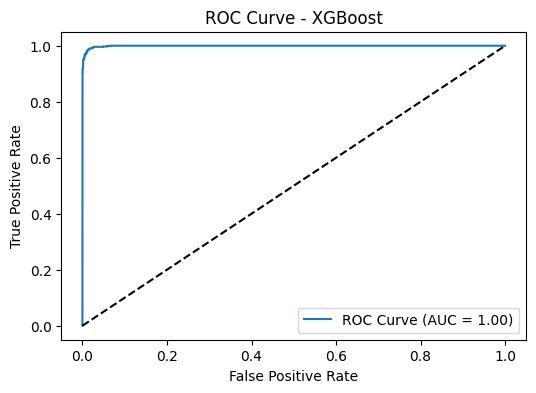

In [67]:
# Plot ROC
plot_roc(y_test_3, y_pred_proba_xgb3)

### Feature Importance - XGBoost without Hyperparameters - Stage 3

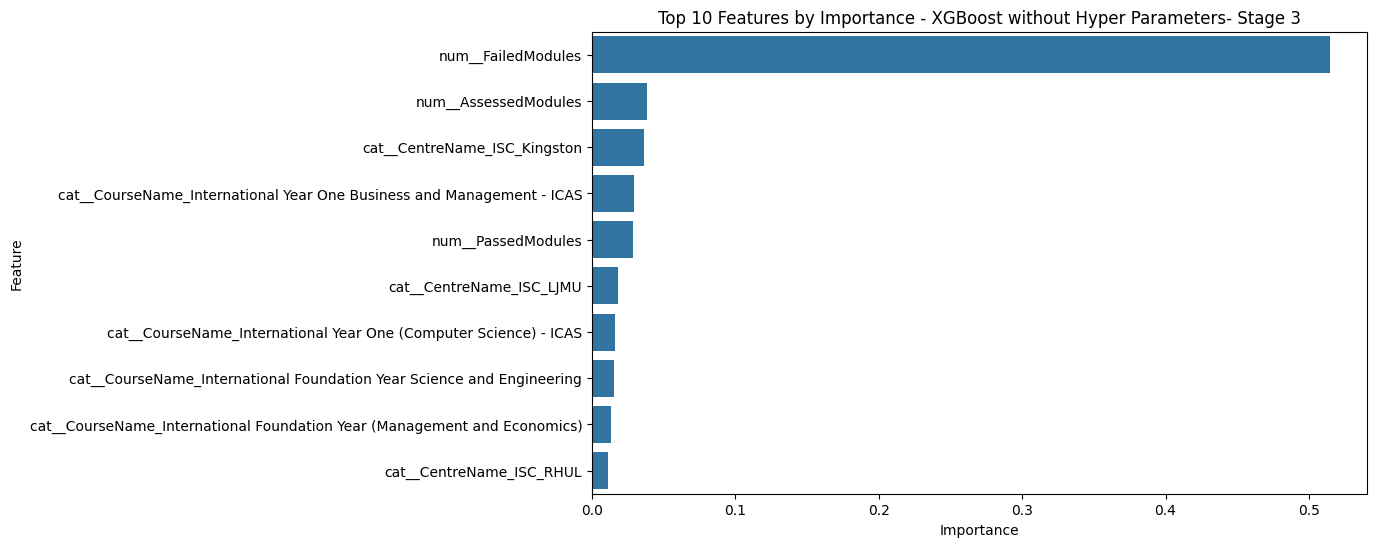

In [68]:
# Feature importance
title = "XGBoost without Hyper Parameters- Stage 3"
plot_feature_importance(xgb_model3.feature_importances_, feature_names3, title)

### The hyperparameter tuning of the learning rate, max depth, and number of estimators has been performed correctly.

### XGBoost with Hyperparameters - Stage 3

Fitting 3 folds for each of 16 candidates, totalling 48 fits

XGBoost Performance (Tuned Parameters):
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': np.float64(5.675657675657676), 'subsample': 1.0}
Accuracy: 0.9870

Confusion Matrix:
[[4212   49]
 [  16  735]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4261
           1       0.94      0.98      0.96       751

    accuracy                           0.99      5012
   macro avg       0.97      0.98      0.97      5012
weighted avg       0.99      0.99      0.99      5012

AUC: 0.9991


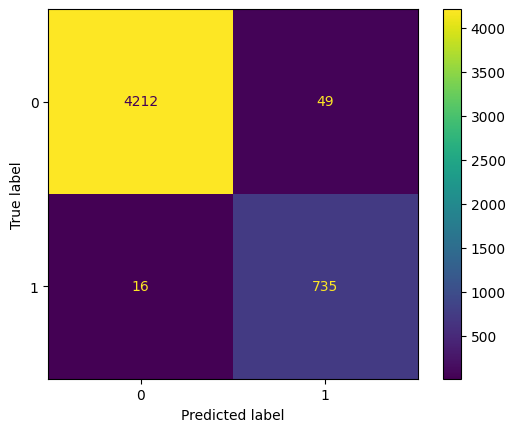

In [69]:
results_grid3 = tune_xgboost_with_class_weights(X_train_encoded3, y_train_3, X_test_encoded3, y_test_3, param_grid_override=None, cv=3)

xgb_tuned3 = results_grid3['xgb_model']
grid_search3 = results_grid3['best_model']
best_params3 = results_grid3['best_params']
y_pred_grid_tuned3 = results_grid3['y_pred']
y_pred_proba_grid_tuned3 = results_grid3['y_pred_proba']
acc_tuned3 = results_grid3['accuracy']

# Create confusion matrix
create_confusion_matrix(y_test_3, y_pred_grid_tuned3)

### ROC Plot - XGBoost with Hyperparameters - Stage 3

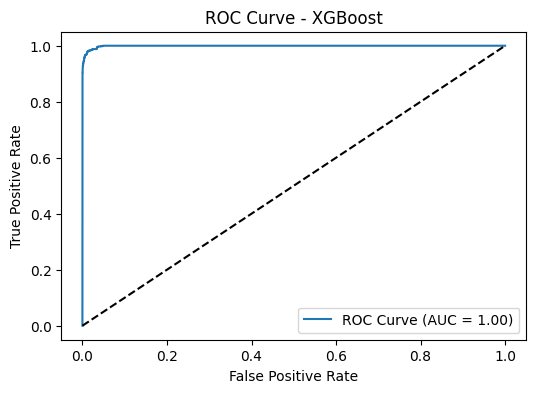

In [70]:
# Plot ROC
plot_roc(y_test_3, y_pred_proba_grid_tuned3)

### Feature Importance - XGBoost with Hyperparameters - Stage 3

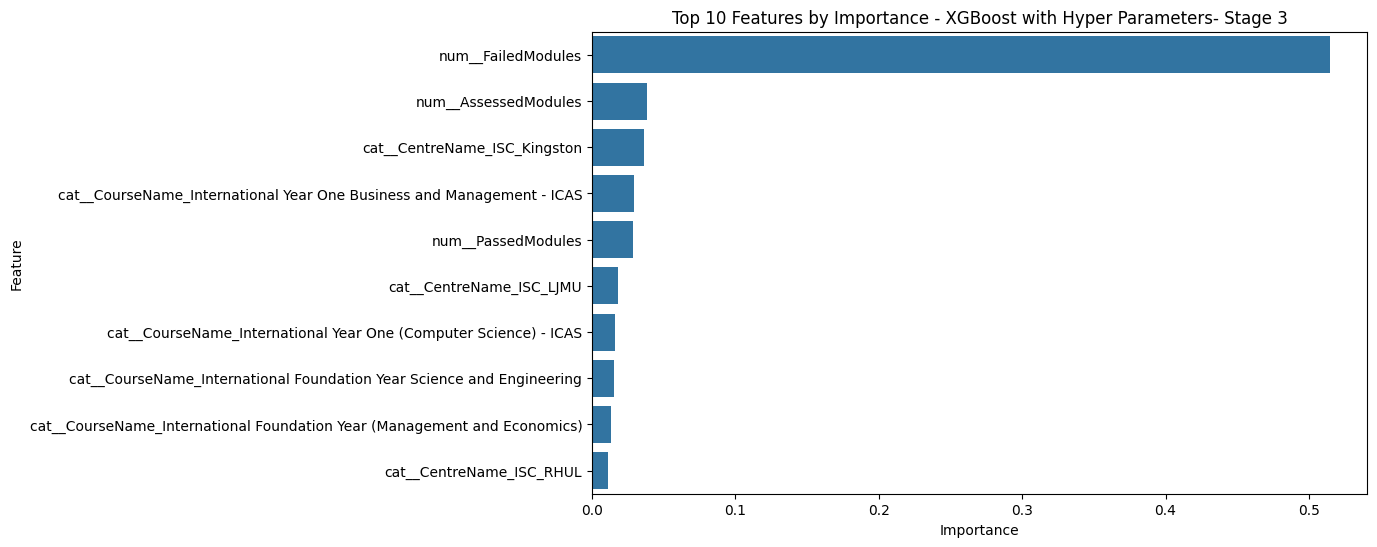

In [71]:
# Feature importance
title = "XGBoost with Hyper Parameters- Stage 3"
plot_feature_importance(xgb_model3.feature_importances_, feature_names3, title)

## The Neural network model has been instantiated correctly and fitted on the training dataset (use 80-20 split)

### Stage 3 - Base Neural Network parameters
  - with Adam Optimizer
  - Learning rate of 0.001
  - L2 Regualrization 0.003
  - Loss 'binary_crossentropy'

### Base Neural Network
- No need for scaling as he data was already scaled during the preprocessing stage
- Even though 2 splits have been performed on data, I have decided that I'll go with first set of the data (X_train_encoded3).

In [72]:
nn_model3 = create_model(X_train_encoded3, optimizer=tf.optimizers.Adam(learning_rate=0.001),
                         regularization=l2(0.003), loss='binary_crossentropy' )

history_reg3 = nn_model3.fit(X_train_encoded3, y_train_3, epochs=20, batch_size=16, validation_data=(X_test_encoded3, y_test_3), verbose=1)

Epoch 1/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8468 - loss: 0.3827 - val_accuracy: 0.9232 - val_loss: 0.2159
Epoch 2/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9329 - loss: 0.2005 - val_accuracy: 0.9463 - val_loss: 0.1689
Epoch 3/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9549 - loss: 0.1536 - val_accuracy: 0.9585 - val_loss: 0.1409
Epoch 4/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9647 - loss: 0.1337 - val_accuracy: 0.9677 - val_loss: 0.1226
Epoch 5/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9722 - loss: 0.1161 - val_accuracy: 0.9747 - val_loss: 0.1101
Epoch 6/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9773 - loss: 0.1042 - val_accuracy: 0.9789 - val_loss: 0.1009
Epoch 7/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9791 - loss: 0.0961 - val_accuracy: 0.9787 - val_loss: 0.0943
Epoch 8/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9834 - loss: 0.0854 - 

### Stage 3 - Base Neural Network Accuaracy and Loss plots

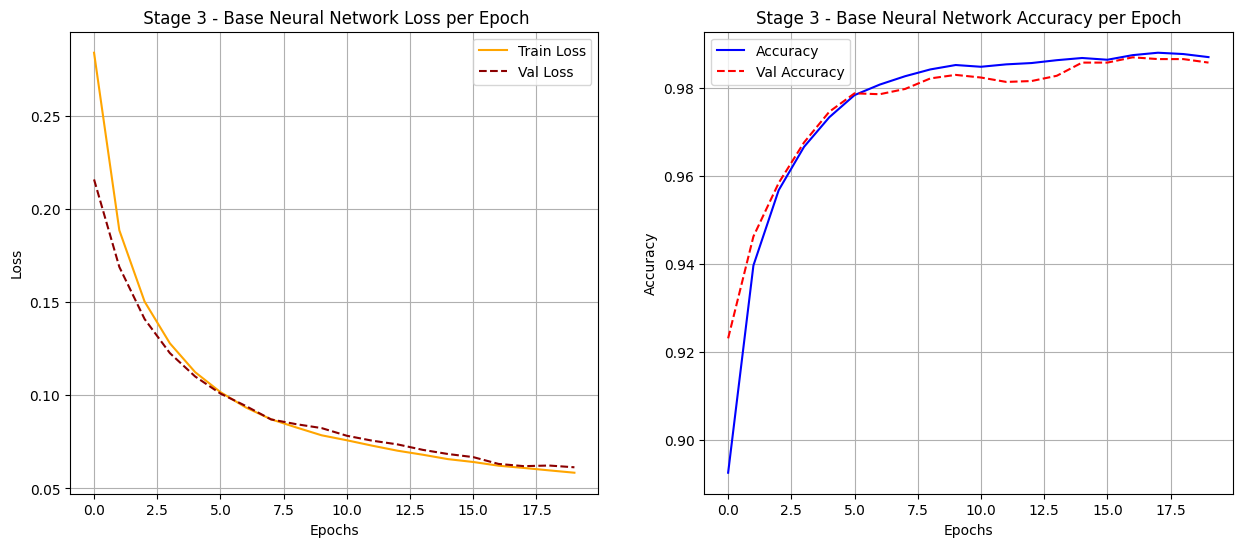

In [73]:
title_loss3 = " Stage 3 - Base Neural Network Loss per Epoch"
title_accuracy3 = "Stage 3 - Base Neural Network Accuracy per Epoch"
plot_accuracy_loss(history_reg3, title_loss3, title_accuracy3)

The most striking observation is the exceptional performance of the "Stage 3 - Base Neural Network" achieves much lower losses and significantly higher accuracies (validation accuracy close to 0.99) compared to any of the Stage 2 models, which typically maxed out around 0.90-0.905 validation accuracy.

- This iteration with L2(0.003) represents a effective and stable configuration for base "Stage 2" model.

  - One hidden layer with 16 Neurons works well for this model.
  - Excellent Regularization Balance: L2 regularization 0.003 seems to have optimized the balance between preventing overfitting and allowing the model to learn effectively.
  - The validation curves are smooth and closely track the training curves, indicating strong generalization.
  - Consistent Optimal Performance: The Adam optimizer with learning_rate=0.001 continues to deliver stable and high-performing results for this task.
  - Overfitting Effectively Managed: The minimal and consistent gap between training and validation performance confirms that overfitting is well-controlled.

### Stage 3 - Confusion metrics and performance indicators for base model
  - Accuracy, confusion matrix, precision, recall and AUC"

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Metrics for  Base Neural Network - Stage 3 
:
Accuracy: 0.9858339984038308
Precision: 0.9619565217391305
Recall: 0.9427430093209055
AUC: 0.9680858909547497
Confusion Matrix:
 [[4233   28]
 [  43  708]]


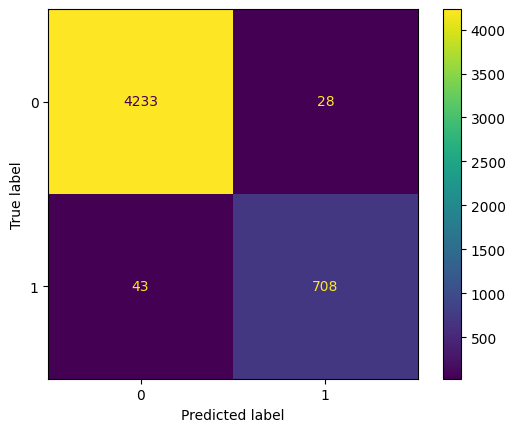

In [74]:
y_pred_nn3 = (nn_model3.predict(X_test_encoded3) > 0.5).astype(int)
y_proba_nn3 = nn_model3.predict(X_test_encoded3)

print_metrics(y_test_3, y_pred_nn3 , " Base Neural Network - Stage 3 \n")

# Create confusion matrix
create_confusion_matrix(y_test_3, y_pred_nn3)

## The hyperparameter tuning of number of neurons, optimisers and activations functions have been set correctly.

### Stage 3 - Neural Network - Tuned model

- with RMSprop Optimizer
- Learning rate of 0.001
- L2 Regualrization 0.003
- Loss 'binary_crossentropy'
- Dropout Rate 0.05
- Epochs 30
- Patience 12
- Early Stopping

In [75]:
input_dim = X_train_encoded3.shape[1]
nn_model_tuned3 = create_model_dropout(input_dim=input_dim, optimizer=tf.optimizers.RMSprop(learning_rate=0.001),
                                      loss='binary_crossentropy', regularization=l2(0.003), dropout_rate=0.05)

nn_tuned_early_stopping3 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, mode='min', restore_best_weights=True)

history_reg_tuned3 = nn_model_tuned3.fit(X_train_encoded3, y_train_3, epochs=30, batch_size=32,
                                         validation_data=(X_test_encoded3, y_test_3), verbose=1,
                                         callbacks=[nn_tuned_early_stopping3])

Epoch 1/30
627/627 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8533 - loss: 0.4086 - val_accuracy: 0.9206 - val_loss: 0.2252
Epoch 2/30
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9319 - loss: 0.2111 - val_accuracy: 0.9473 - val_loss: 0.1689
Epoch 3/30
627/627 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9535 - loss: 0.1668 - val_accuracy: 0.9583 - val_loss: 0.1473
Epoch 4/30
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9621 - loss: 0.1495 - val_accuracy: 0.9669 - val_loss: 0.1346
Epoch 5/30
627/627 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9665 - loss: 0.1351 - val_accuracy: 0.9735 - val_loss: 0.1249
Epoch 6/30
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9695 - loss: 0.1292 - val_accuracy: 0.9741 - val_loss: 0.1171
Epoch 7/30
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9702 - loss: 0.1222 - val_accuracy: 0.9753 - val_loss: 0.1127
Epoch 8/30
627/627 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9715 - loss: 0.1158 - val_accuracy: 0.

### Stage 3 - Tuned Neural Network Accuaracy and Loss plots

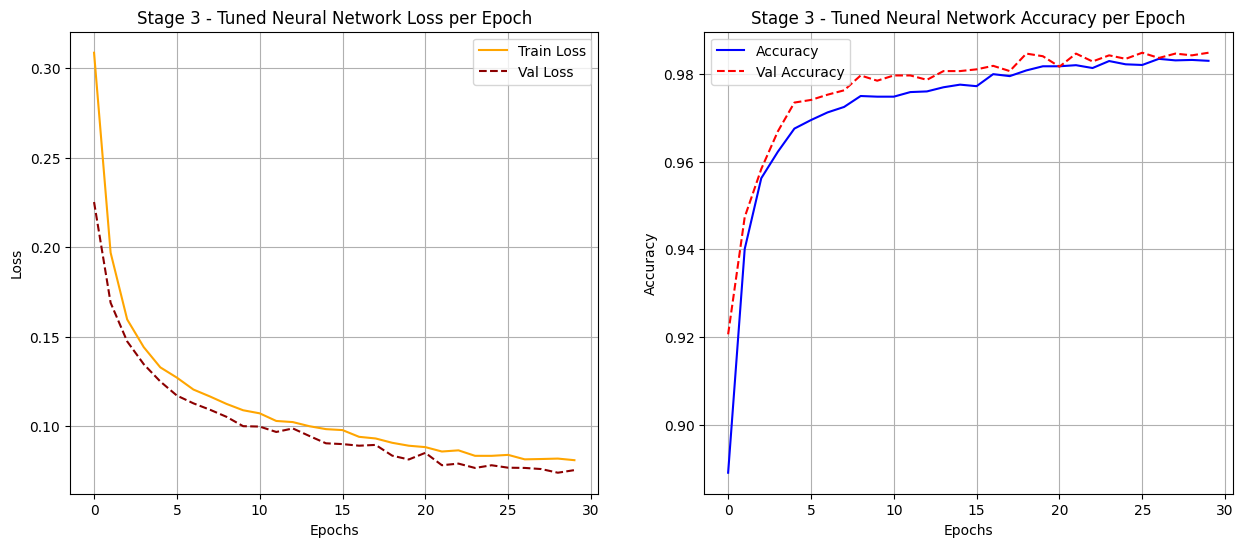

In [76]:
title_loss_tuned3 = "Stage 3 - Tuned Neural Network Loss per Epoch"
title_accuracy_tuned3 = "Stage 3 - Tuned Neural Network Accuracy per Epoch"
plot_accuracy_loss(history_reg_tuned3, title_loss_tuned3, title_accuracy_tuned3)

### Stage 3 - Confusion metrics and performance indicators for tuned model
  - Accuracy, confusion matrix, precision, recall and AUC"

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Metrics for  Tuned Neural Network - Stage 3 
:
Accuracy: 0.9842378292098962
Precision: 0.9577656675749319
Recall: 0.9360852197070573
AUC: 0.964404966107929
Confusion Matrix:
 [[4230   31]
 [  48  703]]


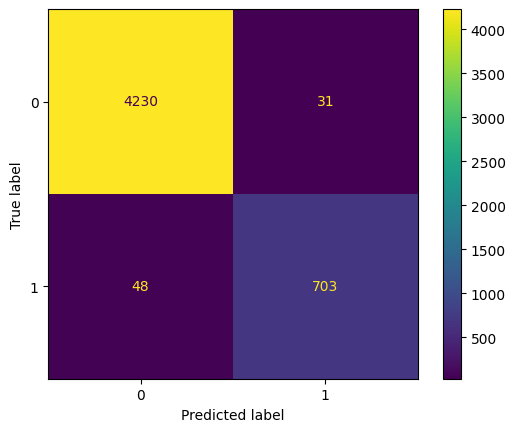

In [77]:
y_pred_tuned3 = (nn_model_tuned3.predict(X_test_encoded3) > 0.5).astype(int)
y_proba_tuned3 = nn_model_tuned3.predict(X_test_encoded3)

print_metrics(y_test_3, y_pred_tuned3 , " Tuned Neural Network - Stage 3 \n")

# Create confusion matrix
create_confusion_matrix(y_test_3, y_pred_tuned3)

### Stage 3 - Neural network metrics with and without Hyperparameters

In [78]:
reg_callback_loss3, reg_callback_acc3 = nn_model3.evaluate(X_test_encoded3, y_test_3)
tuned_callback_loss3, tuned_callback_acc3 = nn_model_tuned3.evaluate(X_test_encoded3, y_test_3)

print('\nBase optimizer:')
print('Test loss:', reg_callback_loss3)
print('Test accuracy:', reg_callback_acc3)

print('\nTuned optimizer:')
print('Test loss:', tuned_callback_loss3)
print('Test accuracy:', tuned_callback_acc3)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9843 - loss: 0.0626
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9822 - loss: 0.0769

Base optimizer:
Test loss: 0.061354056000709534
Test accuracy: 0.985834002494812

Tuned optimizer:
Test loss: 0.07399661839008331
Test accuracy: 0.9842378497123718


### The metrics with and without hyperparameter tuning have been printed correctly and compared. Metrics include: Accuracy, confusion matrix, precision, recall and AUC on the test set



### Comparison of metrics
  - Stage 2 and Stage 3 XGBoost(Base and Tuned)
  - Stage 2 and Stage 3 Neural Network(Base and Tuned)

In [79]:
print("\n XGBoost - Stage 2\n")
print_metrics(y_test_2, y_pred_xgb2 , "XGBoost - Stage 2")
print_metrics(y_test_2, y_pred_grid_tuned2, "XGBoost - Stage 2 - Tuned")

print("\n XGBoost - Stage 3\n")
print_metrics(y_test_3, y_pred_xgb3, "XGBoost - Stage 3")
print_metrics(y_test_3, y_pred_tuned3, "XGBoost - Stage 3 - Tuned")

print("\n Neural Network - Stage 2\n")
print_metrics(y_test_2, y_pred_nn2, "Neural Network - Stage 2")
print_metrics(y_test_2, y_pred_tuned2, "Neural Network - Stage 2 - Tuned")

print("\n Neural Network - Stage 1\n")
print_metrics(y_test_3, y_pred_nn3, "Neural Network - Stage 3")
print_metrics(y_test_3, y_pred_tuned3 , "Neural Network - Stage 3 - Tuned")


 XGBoost - Stage 2


Metrics for XGBoost - Stage 2:
Accuracy: 0.8664252665459666
Precision: 0.5274621212121212
Recall: 0.7714681440443213
AUC: 0.827014373269513
Confusion Matrix:
 [[3750  499]
 [ 165  557]]

Metrics for XGBoost - Stage 2 - Tuned:
Accuracy: 0.8615972641319654
Precision: 0.515426497277677
Recall: 0.7867036011080333
AUC: 0.8305134856563936
Confusion Matrix:
 [[3715  534]
 [ 154  568]]

 XGBoost - Stage 3


Metrics for XGBoost - Stage 3:
Accuracy: 0.9896249002394254
Precision: 0.9616908850726552
Recall: 0.9693741677762983
AUC: 0.981284126835814
Confusion Matrix:
 [[4232   29]
 [  23  728]]

Metrics for XGBoost - Stage 3 - Tuned:
Accuracy: 0.9842378292098962
Precision: 0.9577656675749319
Recall: 0.9360852197070573
AUC: 0.964404966107929
Confusion Matrix:
 [[4230   31]
 [  48  703]]

 Neural Network - Stage 2


Metrics for Neural Network - Stage 2:
Accuracy: 0.8972037819352243
Precision: 0.7072691552062869
Recall: 0.4986149584487535
AUC: 0.7317739419214819
Confusion Matrix:

## Compare the results of the XGBOOST and Neural network models on the Stage 3 dataset Vs the Stage 2 dataset

- On the Stage 3 dataset, both XGBoost and Neural Network models outperformed their Stage 2 counterparts due to the availability of richer and more complete student data. XGBoost showed higher accuracy and AUC in Stage 3, with clearer feature importance aiding interpretability. Neural Networks also demonstrated improved precision and overall predictive performance, particularly in the optimised version. In contrast, Stage 2 models had lower recall, reflecting greater uncertainty with mid-course data. Overall, Stage 3 results confirm that predictive power increases with time, though Stage 2 still offers valuable insights for earlier interventions, especially when models are properly tuned.

### Comparison of Metrics for XGBoost and Neural Network for all stages

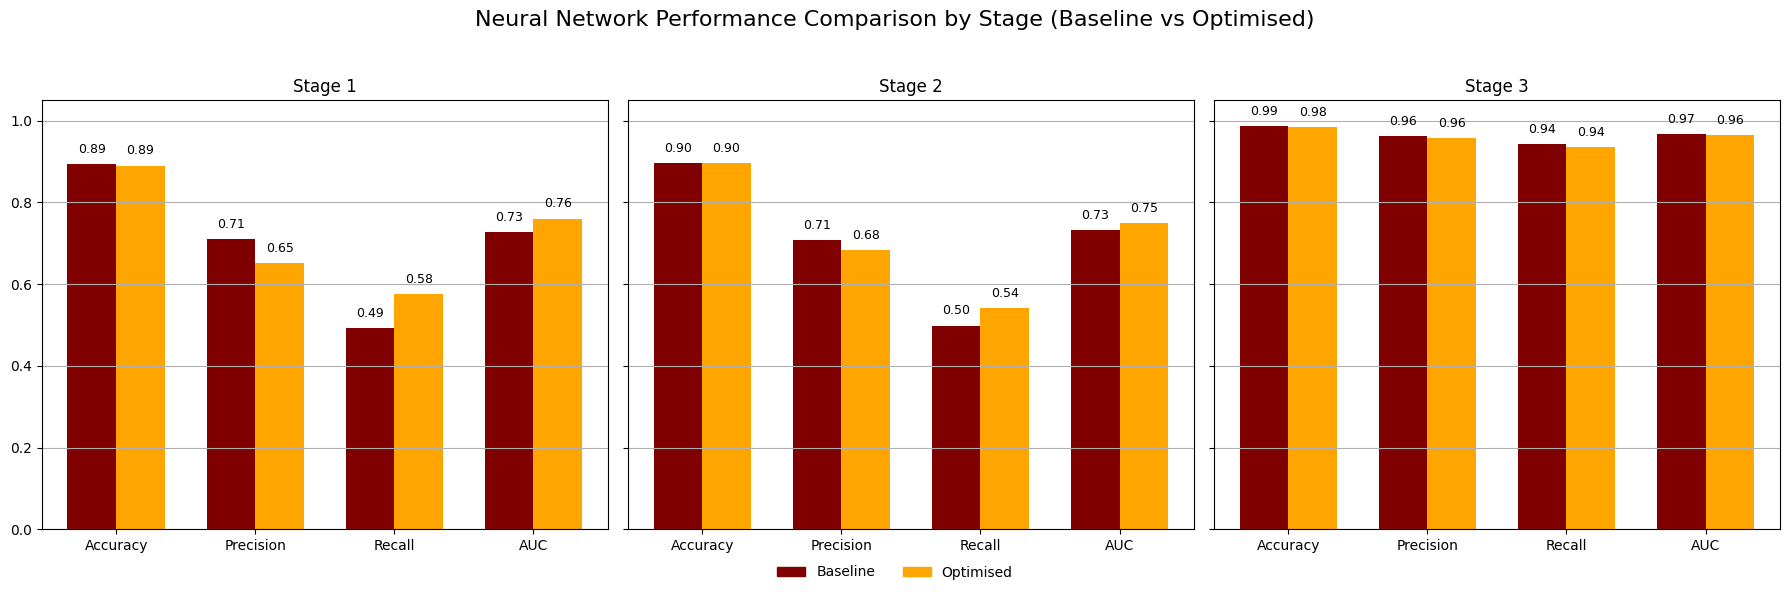

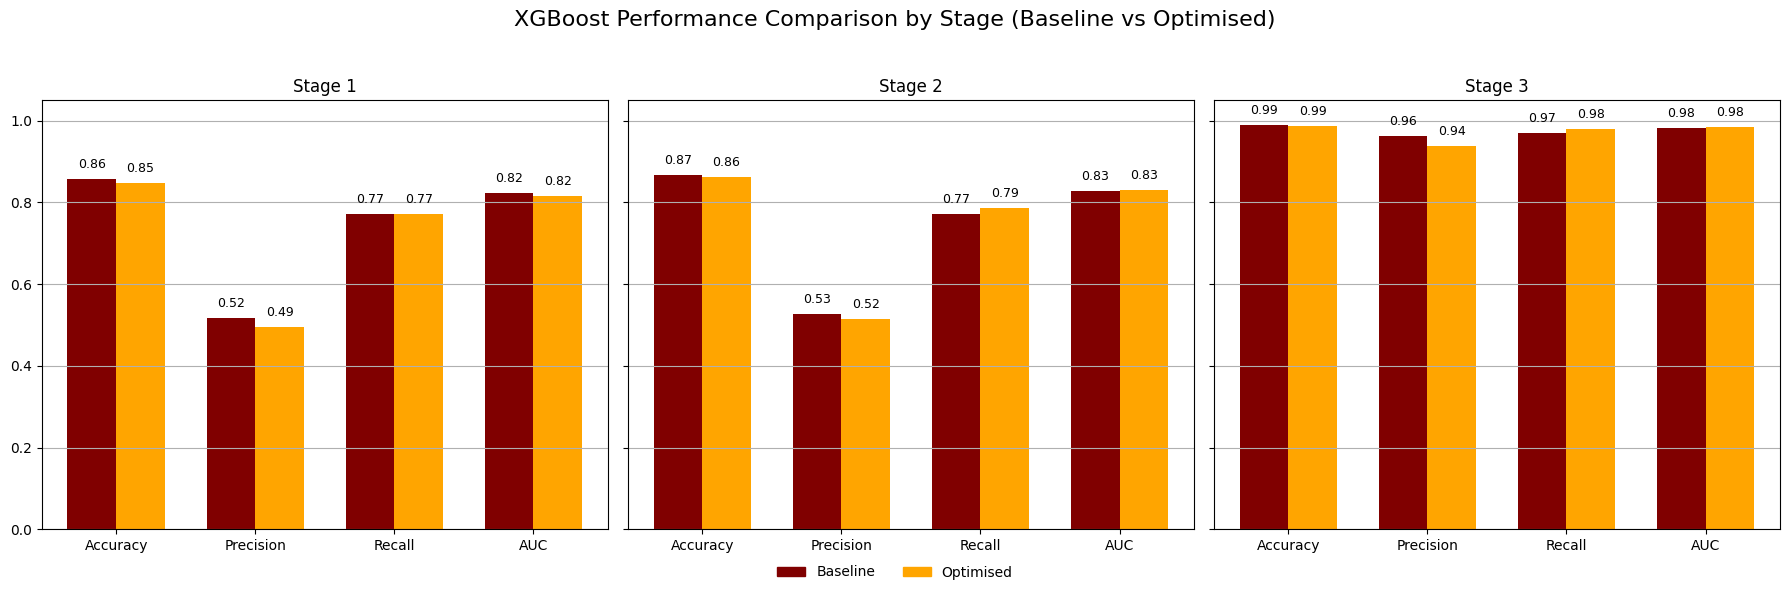

In [112]:
# Plot comparing all the performances by Stage
title1 = 'Neural Network Performance Comparison by Stage'

plot_nn_performance_comparison_by_stage(
    y_test, y_pred_nn, y_pred_tuned,
    y_test_2, y_pred_nn2, y_pred_tuned2,
    y_test_3, y_pred_nn3, y_pred_tuned3, title=title1
)
# XGBoost Plots
title2 = 'XGBoost Performance Comparison by Stage'

plot_nn_performance_comparison_by_stage(
    y_test, y_pred_xgb, y_pred_grid_tuned,
    y_test_2, y_pred_xgb2, y_pred_grid_tuned2,
    y_test_3, y_pred_xgb3, y_pred_grid_tuned3, title=title2
)

## Explaination as to why results are different
#### Below are the reasons for different performances in Stage 2 and Stage 3

 - While the core machine learning model code (e.g., for Neural Networks) might have remained largely consistent between Stage 2 and Stage 3, the underlying datasets and their preprocessing differed significantly, leading to the observed performance variations. The primary distinctions are as follows:

   - Feature Count:

      - Stage 2: The initial dataset contained 17 raw features. After preprocessing (likely including one-hot encoding for categorical variables), these were expanded to 384 features.
      - Stage 3: The dataset for Stage 3 started with an increased number of raw features, totaling 20 features. Post-preprocessing, these were transformed into 385 features. This implies that Stage 3 either introduced new raw features or handled existing ones differently, resulting in one additional processed feature compared to Stage 2.
  - Missing Value Handling:

      - Stage 2: During the data preprocessing for Stage 2, 208 rows that contained null values were identified and subsequently dropped from the dataset. This strategy was likely employed because the proportion of missing data was considered minimal (e.g., less than 2% as discussed previously).
      - Stage 3: In contrast, the Stage 3 dataset presented a much more substantial challenge with missing values. There were 2301 rows found to have nulls. Since this quantity was significantly higher, exceeding a threshold like 25% of the overall data, simply dropping these rows would have led to unacceptable data loss. As a result, all missing values in Stage 3 were imputed using appropriate strategies (e.g., mean/median for numerical features, mode for categorical features).

# Declaration
By submitting your project, you indicate that the work is your own and has been created with academic integrity. Refer to the **Cambridge plagiarism regulations**.
